# Bài tập — Thị giác máy tính (121036)

## CLAHE · Ngưỡng thích nghi bằng ảnh tích phân · Hough đa tỉ lệ

**Nhóm:** 04  
**Thành viên (MSSV — Họ tên):**
1. 075205018417 - Lê Quang Mỹ
2. 075205014385 - Phan Hồng Anh
3. 075205008579 - Lê Tuấn Kiệt
4. 075205006453 - Nguyễn Quốc Việt
5. 060205010772 - Nguyễn Huy Hoàng
6. 087205009558 - Trần Lê Quang
7. 2251120033 - Nguyễn Bùi Minh Nhật

---

### Quy định về việc dùng công cụ AI

| | **Phần cài đặt** | **Phần thí nghiệm minh họa** |
|---|---|---|
| **Nội dung** | Các hàm trong mục `Cài đặt` của mỗi kỹ thuật | Chọn ảnh, dựng bộ ảnh, quét tham số, vẽ hình, so sánh với thuật toán đã học |
| **Công cụ AI** | ❌ **Không được dùng** — kể cả để gợi ý, sửa lỗi hay giải thích mã | ✅ **Được dùng** — để sinh/chọn ảnh phù hợp và dựng khung thí nghiệm |
| **Ràng buộc** | Tự viết hoàn toàn, chỉ dùng thư viện trong danh sách cho phép | **Mọi prompt đã dùng phải được chép nguyên văn vào notebook**, ngay trên ô mã tương ứng |

Trước **mỗi** ô mã ở phần thí nghiệm có dùng AI hỗ trợ, chèn một ô markdown theo đúng mẫu ở ô kế tiếp.
Ô mã nào không có ô markdown này được hiểu là do các em tự viết.
**Thí nghiệm dùng AI mà không khai báo prompt sẽ không được tính điểm cho phần đó.**

### ⚙️ Có dùng AI hỗ trợ

**Công cụ:** *(tên công cụ, phiên bản nếu biết)*

**Mục đích:** *(sinh ảnh thử / dựng vòng lặp quét tham số / vẽ lưới ảnh / ...)*

**Prompt:**

> *(chép nguyên văn prompt đã dùng — không tóm tắt, không viết lại)*

**Đã sửa lại những gì:** *(mô tả ngắn phần các em phải sửa để chạy đúng)*

*(Đây là ô mẫu — sao chép ô này và điền vào mỗi chỗ cần khai báo. Giữ nguyên ô mẫu này ở đây.)*

---
## 0. Chuẩn bị

Thư viện được phép dùng trong **phần cài đặt**: `numpy`, `matplotlib`, `time`/`timeit`.

`cv2`, `scipy`, `skimage` chỉ được gọi trong các ô có nhãn **`ĐỐI CHIẾU`** hoặc trong phần
thí nghiệm khi so sánh với thuật toán đã học. Không được gọi chúng bên trong các hàm phải nộp.

In [101]:
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["image.cmap"]     = "gray"
plt.rcParams["image.interpolation"] = "nearest"

### 0.1 Tiện ích hiển thị *(cung cấp sẵn — không cần sửa)*

`show_grid` dùng để trình bày lưới ảnh khi quét tham số.

In [102]:
def show_grid(images, titles=None, ncols=4, figw=3.0, suptitle=None, vmin=0, vmax=255):
    """Hiển thị một danh sách ảnh xám thành lưới.

    images : list các mảng 2 chiều
    titles : list nhãn tương ứng (có thể None)
    """
    n = len(images)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figw * ncols, figw * nrows * 1.12))
    axes = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(axes):
        ax.axis("off")
        if i < n:
            ax.imshow(images[i], vmin=vmin, vmax=vmax)
            if titles is not None:
                ax.set_title(titles[i], fontsize=9)
    if suptitle:
        fig.suptitle(suptitle, fontsize=12)
    fig.tight_layout()
    plt.show()


def show_hist(img, ax=None, title=None):
    """Vẽ lược đồ xám của một ảnh uint8."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 2.2))
    ax.hist(np.asarray(img).ravel(), bins=256, range=(0, 255), color="#195AA0")
    ax.set_xlim(0, 255)
    ax.set_yticks([])
    if title:
        ax.set_title(title, fontsize=9)
    return ax

### 0.2 Ảnh dùng trong bài

Nạp ảnh của nhóm vào đây. Yêu cầu về bộ ảnh được nêu riêng ở phần thí nghiệm của từng kỹ thuật —
**đọc trước** rồi hãy chọn ảnh, vì mỗi kỹ thuật cần một loại ảnh khác nhau để hiệu ứng lộ ra được.

Nếu nạp ảnh màu, chuyển sang ảnh xám `uint8` trước khi dùng.

In [103]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# TODO: nạp ảnh của nhóm.
#   img = ...   # mảng (H, W) dtype uint8

def load_gray_uint8(path):
    """Load image as grayscale uint8."""
    img = Image.open(path).convert('L')
    return np.array(img, dtype=np.uint8)

IMAGES = {
    "flat_noise": load_gray_uint8("images/01_flat_noise.png"), 
    "uneven_light": load_gray_uint8("images/02_uneven_light.png"),
    "flat_document": load_gray_uint8("images/03_flat_document.png"),
    "good_contrast": load_gray_uint8("images/04_good_contrast.png"),
    "hough_vertical": load_gray_uint8("images/05_hough_vertical.png"),
    "hough_long_short": load_gray_uint8("images/06_hough_long_short.png"),
} # ví dụ: {"nhan_container": img1, "chung_tu": img2}

---
---
# 1. Kỹ thuật 1 — CLAHE

Lý thuyết: xem mục 2 của tài liệu bổ trợ.

## 1.1 Cài đặt — ❌ KHÔNG dùng AI

Thư viện được phép: `numpy` (kể cả `np.cumsum`, `np.bincount`, `np.histogram`), `matplotlib`.

Bị cấm: `cv2.createCLAHE`, `cv2.equalizeHist`, `skimage.exposure.equalize_adapthist`,
`scipy.ndimage.map_coordinates`.

In [104]:
import numpy as np
def clip_histogram(hist, clip_limit):
    """Cắt và phân phối lại lược đồ xám.

    hist       : mảng (L,) số nguyên — lược đồ của MỘT ô.
    clip_limit : hệ số s_max như OpenCV. Ngưỡng cắt tuyệt đối được tính bằng
                 beta = max(1, int(clip_limit * tổng số pixel / L)).

    Trả về     : mảng (L,) đã cắt, tổng giữ nguyên (sai số <= L do làm tròn).
    """
    hist = np.asarray(hist, dtype=np.int64).copy()
    L = hist.size
    tong = int(hist.sum())

    beta = max(1, int(clip_limit * tong / L))
    phan_du = int(np.maximum(hist - beta, 0).sum())
    hist = np.minimum(hist, beta)

    moi_muc = phan_du // L
    so_muc_con_lai = phan_du % L
    hist += moi_muc
    hist[:so_muc_con_lai] += 1

    return hist

In [105]:
def build_tile_luts(img, grid=(8, 8), clip_limit=2.0):
    """Dựng bảng tra cho từng ô của lưới.

    img   : (H, W) uint8
    grid  : (Gy, Gx) số ô theo hàng và cột

    Trả về: mảng (Gy, Gx, L) uint8 — bảng tra của từng ô.
    """
    H, W = img.shape
    Gy, Gx = grid
    L = 256
    luts = np.zeros((Gy, Gx, L), dtype=np.uint8)

    for i in range(Gy):
        y1 = i * H // Gy
        y2 = (i + 1) * H // Gy

        for j in range(Gx):
            x1 = j * W // Gx
            x2 = (j + 1) * W // Gx
            o = img[y1:y2, x1:x2]

            hist = np.bincount(o.ravel(), minlength=L)
            hist = clip_histogram(hist, clip_limit)
            cdf = np.cumsum(hist)
            lut = np.rint(cdf * (L - 1) / o.size)
            luts[i, j] = np.clip(lut, 0, L - 1).astype(np.uint8)

    return luts

In [106]:
def clahe(img, grid=(8, 8), clip_limit=2.0):
    """CLAHE đầy đủ: dựng bảng tra từng ô, rồi nội suy song tuyến GIỮA CÁC BẢNG TRA.

    Lưu ý: nội suy giá trị bảng tra T_ij[v] (bốn số vô hướng), KHÔNG nội suy giữa bốn ảnh.

    img   : (H, W) uint8
    Trả về: (H, W) uint8
    """
    H, W = img.shape
    Gy, Gx = grid
    luts = build_tile_luts(img, grid, clip_limit)

    vi_tri_y = (np.arange(H) + 0.5) * Gy / H - 0.5
    vi_tri_x = (np.arange(W) + 0.5) * Gx / W - 0.5

    y0 = np.floor(vi_tri_y).astype(int)
    x0 = np.floor(vi_tri_x).astype(int)
    y1 = y0 + 1
    x1 = x0 + 1

    trong_so_y = vi_tri_y - y0
    trong_so_x = vi_tri_x - x0

    y0 = np.clip(y0, 0, Gy - 1)
    y1 = np.clip(y1, 0, Gy - 1)
    x0 = np.clip(x0, 0, Gx - 1)
    x1 = np.clip(x1, 0, Gx - 1)

    gia_tri_00 = luts[y0[:, None], x0[None, :], img].astype(float)
    gia_tri_01 = luts[y0[:, None], x1[None, :], img].astype(float)
    gia_tri_10 = luts[y1[:, None], x0[None, :], img].astype(float)
    gia_tri_11 = luts[y1[:, None], x1[None, :], img].astype(float)

    trong_so_y = trong_so_y[:, None]
    trong_so_x = trong_so_x[None, :]

    hang_tren = (1 - trong_so_x) * gia_tri_00 + trong_so_x * gia_tri_01
    hang_duoi = (1 - trong_so_x) * gia_tri_10 + trong_so_x * gia_tri_11
    ket_qua = (1 - trong_so_y) * hang_tren + trong_so_y * hang_duoi

    return np.clip(np.rint(ket_qua), 0, 255).astype(np.uint8)

**Ô kiểm tra nhanh trong lúc viết** *(tùy chọn, không chấm điểm — dùng để tự dò lỗi)*

In [107]:
# Gợi ý dùng khi đang gỡ lỗi:
#   - vẽ một lát cắt ngang của ảnh ra: nếu thấy bậc nhảy tuần hoàn đúng bằng bề rộng ô
#     thì phần nội suy đang sai.
#   - kiểm tra mọi bảng tra không giảm.

## 1.2 Thí nghiệm minh họa — ✅ được dùng AI *(nhớ khai báo prompt)*

### (a) Ảnh hưởng của tham số

Quét `clip_limit` và `grid` qua **ít nhất bốn giá trị mỗi tham số**, trình bày dạng lưới ảnh.

Chọn ảnh sao cho hiệu ứng **nhìn thấy được**:
- `clip_limit` chỉ lộ tác dụng trên ảnh có **vùng phẳng nhiều nhiễu**;
- `grid` chỉ lộ tác dụng trên ảnh có **ánh sáng không đều theo vùng**.

Có thể phải dùng hai ảnh khác nhau cho hai tham số.

⚙️ Có dùng AI hỗ trợ

Công cụ: ChatGPT

Mục đích: Hỗ trợ viết vòng lặp quét nhiều giá trị clip_limit của CLAHE và trình bày kết quả dưới dạng lưới ảnh để so sánh ảnh hưởng của tham số.

Prompt:

Hãy giúp tôi viết code quét tham số clip_limit của CLAHE qua ít nhất 4 giá trị. Sử dụng ảnh IMAGES["flat_noise"], giữ cố định grid=(8, 8), chạy hàm clahe với từng giá trị clip_limit và hiển thị các kết quả dưới dạng lưới ảnh để dễ so sánh.

Đã sửa lại những gì: Điều chỉnh các giá trị clip_limit thành [1.0, 2.0, 3.0, 5.0], sử dụng hàm clahe và show_grid đã xây dựng trong bài, đồng thời đặt tiêu đề cho từng ảnh và tiêu đề chung của lưới ảnh.

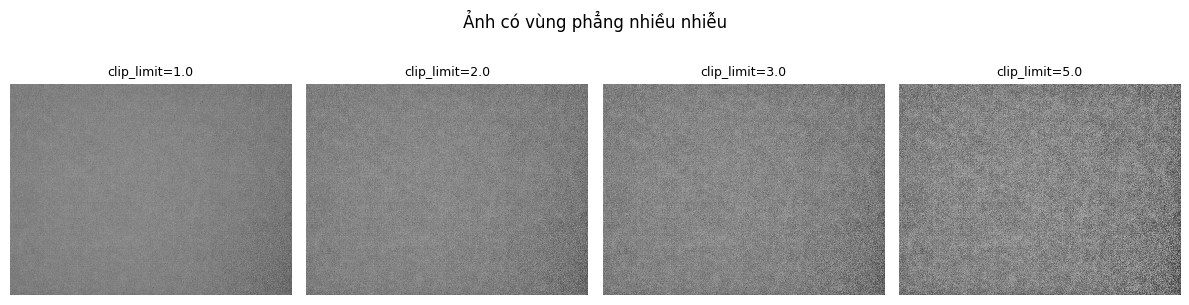

In [108]:
# TODO (a): quét clip_limit

img_test_noise = IMAGES["flat_noise"]

clip_limits = [1.0, 2.0, 3.0, 5.0]
results_clip = []

for limit in clip_limits:
    result = clahe(img_test_noise, grid=(8, 8), clip_limit=limit)
    results_clip.append(result)

titles_clip = [f"clip_limit={c}" for c in clip_limits]
show_grid(results_clip, titles=titles_clip, ncols=4, suptitle="Ảnh có vùng phẳng nhiều nhiễu")


⚙️ Có dùng AI hỗ trợ

Công cụ: ChatGPT

Mục đích: Hỗ trợ viết vòng lặp quét nhiều giá trị grid của CLAHE và trình bày kết quả dưới dạng lưới ảnh để so sánh ảnh hưởng của kích thước lưới.

Prompt:

Hãy giúp tôi viết code quét tham số grid của CLAHE qua ít nhất 4 giá trị. Sử dụng ảnh IMAGES["uneven_light"], giữ cố định clip_limit=2.0, chạy hàm clahe với từng giá trị grid và hiển thị các kết quả dưới dạng lưới ảnh để dễ so sánh.

Đã sửa lại những gì: Chọn các giá trị grid là [(4, 4), (8, 8), (16, 16), (32, 32)], sử dụng ảnh IMAGES["uneven_light"], giữ cố định clip_limit=2.0, đồng thời dùng hàm show_grid đã có trong bài để hiển thị và đặt tiêu đề cho từng kết quả.

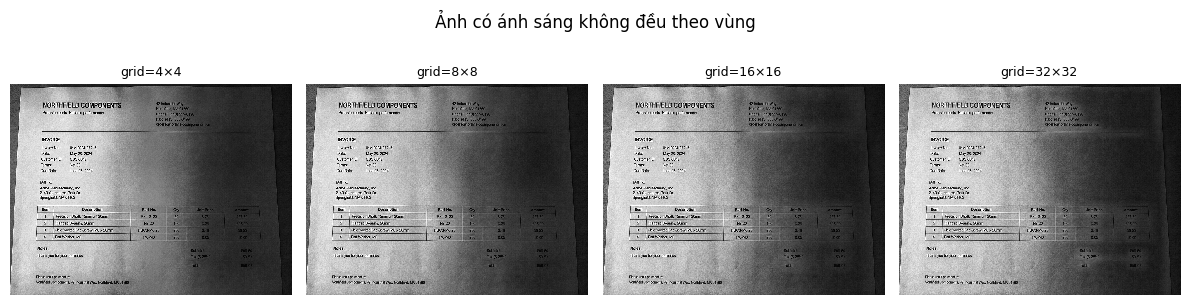

In [109]:
# TODO (a): quét grid

img_test_uneven = IMAGES["uneven_light"]

grids = [(4, 4), (8, 8), (16, 16), (32, 32)]
results_grid = []

for g in grids:
    result = clahe(img_test_uneven, grid=g, clip_limit=2.0)
    results_grid.append(result)

titles_grid = [f"grid={g[0]}×{g[1]}" for g in grids]
show_grid(results_grid, titles=titles_grid, ncols=4, suptitle="Ảnh có ánh sáng không đều theo vùng")


**Nhận xét (a):**

**Tham số `clip_limit`:**
- `clip_limit` càng nhỏ thì ngưỡng cắt histogram $\beta$ càng thấp, histogram bị cắt mạnh hơn và phần phiếu dư được phân phối lại nhiều hơn. Nhờ vậy CLAHE hạn chế khuếch đại tương phản và nhiễu cục bộ mạnh hơn.
- `clip_limit` càng lớn thì $\beta$ càng cao, histogram bị cắt ít hơn; khi giới hạn đủ lớn có thể không còn cột nào bị cắt và kết quả dần tiến về AHE. Trên vùng nền gần phẳng có nhiễu, điều này làm các biến thiên nhỏ do nhiễu dễ bị khuếch đại.
- Ảnh có vùng phẳng nhiều nhiễu được chọn để tác động của giới hạn cắt thể hiện rõ qua mức nhiễu nền sau xử lý.

**Tham số `grid`:**
- Khi grid nhỏ (4×4): số ô ít, mỗi ô lớn, histogram được tính trên vùng rộng nên khả năng thích nghi theo từng vùng còn hạn chế.
- Khi grid lớn (16×16, 32×32): số ô nhiều, mỗi ô nhỏ, tương phản cục bộ được điều chỉnh chi tiết hơn nhưng có thể làm nhiễu cục bộ rõ hơn hoặc tạo cảm giác ranh giới ô nếu lưới quá mịn.
- Ảnh có ánh sáng không đều giúp thấy rõ sự đánh đổi giữa khả năng thích nghi theo vùng và tính liên tục của kết quả.

### (b) So sánh với thuật toán đã học

Đặt cạnh nhau, **trên cùng một ảnh**:

1. kéo giãn tương phản tuyến tính
2. hiệu chỉnh gamma
3. cân bằng lược đồ xám toàn cục (HE)
4. CLAHE

Kèm **lược đồ xám của từng kết quả** (dùng `show_hist`).

Bắt buộc chỉ ra:
- một ảnh mà **CLAHE thắng rõ rệt**;
- một ảnh mà **CLAHE thua** một trong ba cách kia — và giải thích vì sao.

### Có dùng AI hỗ trợ

**Công cụ:** ChatGPT (GPT-5.6 Sol)

**Mục đích:** Dựng thí nghiệm so sánh kéo giãn tương phản tuyến tính, Gamma, HE toàn cục và CLAHE trên cùng một ảnh, đồng thời vẽ histogram của từng kết quả.

**Prompt đã dùng:**
Dựa vào các hàm đã viết, hãy code ra một thí nghiệm so sánh kéo giãn tương phản tuyến tính, Gamma, HE toàn cục và CLAHE trên cùng một ảnh, đồng thời vẽ histogram của từng kết quả. Hãy sử dụng ảnh `uneven_light` có sẵn trong bộ ảnh của notebook và tự kiểm tra kết quả sau khi chạy.

**Đã sửa lại những gì:**
- Tự chọn tham số Gamma, CLAHE và hai ảnh dùng để minh họa trường hợp thắng/thua.
- Tự chạy, kiểm tra histogram và điều chỉnh phần nhận xét theo kết quả thực tế.


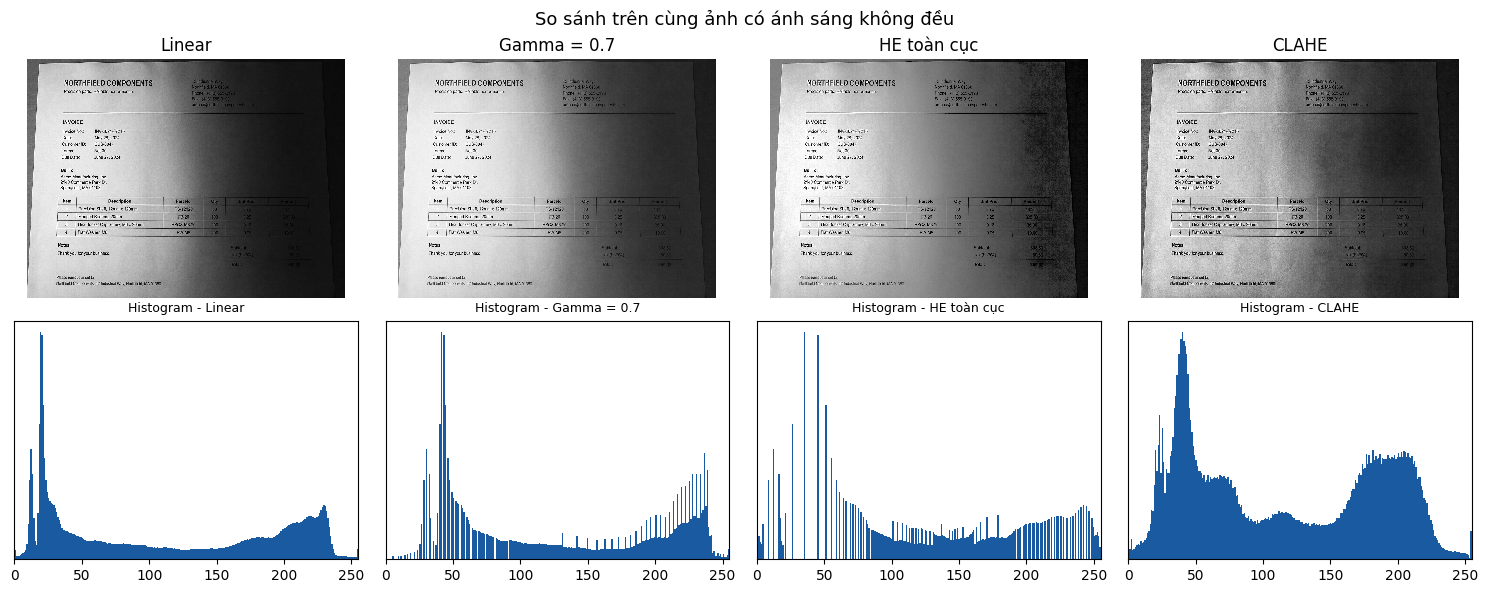

In [110]:
# ==============================
# 1. Các hàm đối chiếu
# ==============================

def linear_stretch_u8(img):
    x = np.asarray(img, dtype=np.float64)

    lo = x.min()
    hi = x.max()

    if hi <= lo:
        return img.copy()

    out = (x - lo) * 255.0 / (hi - lo)

    return np.clip(
        np.rint(out),
        0,
        255
    ).astype(np.uint8)


def gamma_u8(img, gamma=0.7):
    x = np.asarray(img, dtype=np.float64) / 255.0

    out = 255.0 * np.power(x, gamma)

    return np.clip(
        np.rint(out),
        0,
        255
    ).astype(np.uint8)


def global_he_u8(img):
    img = np.asarray(img, dtype=np.uint8)

    hist = np.bincount(
        img.ravel(),
        minlength=256
    )

    cdf = np.cumsum(hist)

    if cdf[-1] == 0:
        return img.copy()

    lut = np.rint(
        255.0 * cdf / cdf[-1]
    )

    lut = np.clip(
        lut,
        0,
        255
    ).astype(np.uint8)

    return lut[img]


# ==============================
# 2. Chọn cùng một ảnh
# ==============================

img_compare = IMAGES["uneven_light"]


# ==============================
# 3. Chạy 4 phương pháp
# ==============================

img_linear = linear_stretch_u8(
    img_compare
)

img_gamma = gamma_u8(
    img_compare,
    gamma=0.7
)

img_he = global_he_u8(
    img_compare
)

img_clahe = clahe(
    img_compare,
    grid=(8, 8),
    clip_limit=2.0
)


results = [
    img_linear,
    img_gamma,
    img_he,
    img_clahe
]

titles = [
    "Linear",
    "Gamma = 0.7",
    "HE toàn cục",
    "CLAHE"
]


# ==============================
# 4. Hiển thị kết quả + histogram
# ==============================

fig, axes = plt.subplots(
    2,
    4,
    figsize=(15, 6)
)

for i, (image, title) in enumerate(
    zip(results, titles)
):

    axes[0, i].imshow(
        image,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axes[0, i].set_title(title)
    axes[0, i].axis("off")

    show_hist(
        image,
        ax=axes[1, i],
        title="Histogram - " + title
    )


fig.suptitle(
    "So sánh trên cùng ảnh có ánh sáng không đều",
    fontsize=13
)

fig.tight_layout()
plt.show()

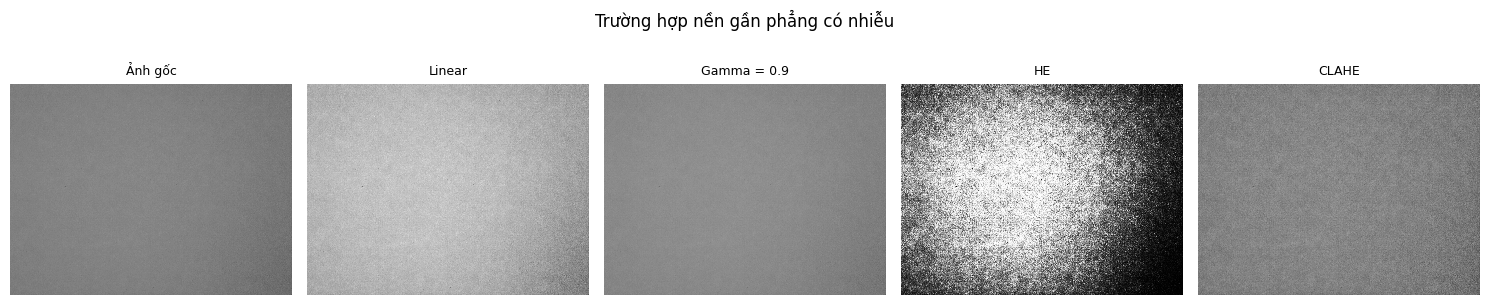

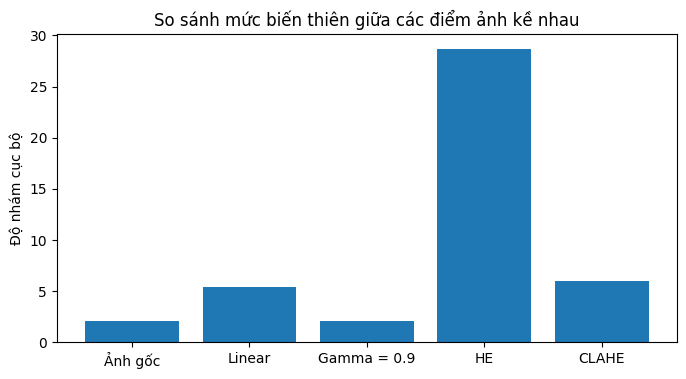

Ảnh gốc     : 2.119
Linear      : 5.403
Gamma = 0.9 : 2.088
HE          : 28.669
CLAHE       : 6.001


In [111]:
# ==============================
# Ảnh dùng để tìm trường hợp
# CLAHE không phải lựa chọn tốt nhất
# ==============================

img_loss = IMAGES["flat_noise"]


# Chạy các phương pháp
loss_linear = linear_stretch_u8(
    img_loss
)

loss_gamma = gamma_u8(
    img_loss,
    gamma=0.9
)

loss_he = global_he_u8(
    img_loss
)

loss_clahe = clahe(
    img_loss,
    grid=(8, 8),
    clip_limit=2.0
)


loss_results = [
    img_loss,
    loss_linear,
    loss_gamma,
    loss_he,
    loss_clahe
]

loss_titles = [
    "Ảnh gốc",
    "Linear",
    "Gamma = 0.9",
    "HE",
    "CLAHE"
]


show_grid(
    loss_results,
    loss_titles,
    ncols=5,
    figw=3.0,
    suptitle="Trường hợp nền gần phẳng có nhiễu"
)


# ==============================
# Đo độ nhám cục bộ
# ==============================

def local_roughness(img):
    x = np.asarray(
        img,
        dtype=np.float64
    )

    dx = np.mean(
        np.abs(
            np.diff(x, axis=1)
        )
    )

    dy = np.mean(
        np.abs(
            np.diff(x, axis=0)
        )
    )

    return (dx + dy) / 2.0


roughness_values = [
    local_roughness(x)
    for x in loss_results
]


# ==============================
# Vẽ biểu đồ
# ==============================

fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.bar(
    loss_titles,
    roughness_values
)

ax.set_ylabel(
    "Độ nhám cục bộ"
)

ax.set_title(
    "So sánh mức biến thiên giữa các điểm ảnh kề nhau"
)

plt.show()


# In kết quả
for name, value in zip(
    loss_titles,
    roughness_values
):
    print(
        f"{name:12s}: {value:.3f}"
    )

**Nhận xét (b):**

-Trên ảnh có ánh sáng không đều, CLAHE cho khả năng làm rõ chi tiết cục bộ tốt hơn vì ảnh được chia thành nhiều ô, mỗi ô có một LUT riêng rồi các LUT được nội suy với nhau.

- Linear, Gamma và HE toàn cục sử dụng một phép biến đổi chung cho toàn ảnh nên khó xử lý đồng thời vùng tối và vùng sáng.

- Trên ảnh có nền gần phẳng và nhiễu nhẹ, CLAHE có thể không phải lựa chọn tốt nhất. Việc tăng tương phản cục bộ có thể làm những biến thiên nhỏ do nhiễu trở nên rõ hơn.

- Dựa trên ảnh kết quả và độ nhám đo được, phương pháp có độ nhám thấp hơn giữ nền mượt hơn. Vì vậy CLAHE không phải lúc nào cũng tốt hơn các phương pháp đơn giản.

---
---
# 2. Kỹ thuật 2 — Ngưỡng thích nghi bằng ảnh tích phân

Lý thuyết: xem mục 3 của tài liệu bổ trợ.

## 2.1 Cài đặt — ❌ KHÔNG dùng AI

Thư viện được phép: `numpy` (kể cả `np.cumsum`), `time`/`timeit`, `matplotlib`.

Bị cấm: `cv2.integral`, `cv2.adaptiveThreshold`, `cv2.boxFilter`, `cv2.blur`,
`scipy.ndimage.uniform_filter`, `skimage.filters.threshold_sauvola`.

In [112]:
def integral_image(img):
    """Ảnh tích phân có đệm viền.

    img   : (H, W)
    Trả về: (H+1, W+1) dtype int64, hàng 0 và cột 0 bằng 0.
    """
    H, W = img.shape
    S = np.zeros((H + 1, W + 1), dtype=np.int64)
    
    # Tính tích phân theo hàng rồi theo cột
    S[1:, 1:] = np.cumsum(np.cumsum(img.astype(np.int64), axis=0), axis=1)
    
    return S

In [113]:
def box_sum(S, y1, x1, y2, x2):
    """Tổng vùng [y1..y2, x1..x2] (bao gồm cả biên) từ ảnh tích phân đã đệm viền.

    Phải vecto hóa được: y1, x1, y2, x2 có thể là mảng cùng shape.
    """
    # Vì S đã được đệm viền 0 ở hàng 0 và cột 0:
    # Tọa độ thực trong S của (y2, x2) là (y2 + 1, x2 + 1)
    return S[y2 + 1, x2 + 1] - S[y1, x2 + 1] - S[y2 + 1, x1] + S[y1, x1]

In [114]:
def local_mean_std(img, radius):
    """Trung bình và độ lệch chuẩn cục bộ, vector hóa bằng ảnh tích phân."""
    x = np.asarray(img, dtype=np.int64)
    h, w = x.shape

    # Dùng đúng integral_image() và box_sum() đã định nghĩa ở hai ô trên.
    S = integral_image(x)
    S2 = integral_image(x * x)

    yy, xx = np.indices((h, w))
    y1 = np.maximum(0, yy - radius)
    x1 = np.maximum(0, xx - radius)
    y2 = np.minimum(h - 1, yy + radius)
    x2 = np.minimum(w - 1, xx + radius)
    area = (y2 - y1 + 1) * (x2 - x1 + 1)

    total = box_sum(S, y1, x1, y2, x2).astype(np.float64)
    total_sq = box_sum(S2, y1, x1, y2, x2).astype(np.float64)
    mean = total / area
    variance = np.maximum(total_sq / area - mean * mean, 0.0)
    return mean, np.sqrt(variance)

In [115]:
def adaptive_threshold(img, radius=15, method="bradley", t=0.15, k=0.34, R=128.0):
    """Nhị phân hóa thích nghi; foreground (I < T) được gán 255."""
    img = np.asarray(img, dtype=np.float64)
    mean, std = local_mean_std(img, radius)
    method = method.lower()

    if method == "bradley":
        threshold = mean * (1 - t)
    elif method == "sauvola":
        threshold = mean * (1 + k * (std / R - 1))
    else:
        raise ValueError("method phải là 'bradley' hoặc 'sauvola'")

    # Theo đặc tả: điểm ảnh tối hơn ngưỡng là foreground.
    return np.where(img < threshold, 255, 0).astype(np.uint8)

## 2.2 Thí nghiệm minh họa — ✅ được dùng AI *(nhớ khai báo prompt)*

### (a) Ảnh hưởng của tham số

Quét `radius` qua **ít nhất năm giá trị** và `t` (hoặc `k`) qua **ít nhất ba giá trị**.

Hai hiện tượng phải xuất hiện được trong lưới ảnh:
- `radius` **quá nhỏ** → nét chữ dày bị **rỗng ruột**;
- `radius` **quá lớn** → phương pháp thoái hóa dần về **ngưỡng toàn cục**.

Chỉ ra vùng giá trị hợp lý và giải thích nó phụ thuộc vào **cái gì trong ảnh**.

## Khai báo sử dụng AI

Công cụ AI sử dụng:
ChatGPT

Mục đích sử dụng:
Hỗ trợ thiết kế thí nghiệm khảo sát ảnh hưởng của tham số radius
và t trong Adaptive Threshold, đề xuất cách lựa chọn giá trị tham số
và cách trình bày nhận xét kết quả.

Prompt đã sử dụng:

Bài toán Adaptive Threshold sử dụng local mean và local standard
deviation, hãy giúp tôi thiết kế thí nghiệm khảo sát ảnh hưởng của
radius và t. Yêu cầu radius ít nhất 5 giá trị, t ít nhất 3 giá trị.
Thể hiện trường hợp radius quá nhỏ gây rỗng ruột chữ và radius
quá lớn làm phương pháp gần giống ngưỡng toàn cục. Hãy gợi ý cách
phân tích kết quả.

Phần đã chỉnh sửa:
- Tự chọn ảnh thử nghiệm.
- Tự chọn các giá trị radius và t.
- Tự chạy code thí nghiệm.
- Tự đánh giá kết quả dựa trên ảnh thực tế.

In [116]:

img_gray = IMAGES["flat_document"]


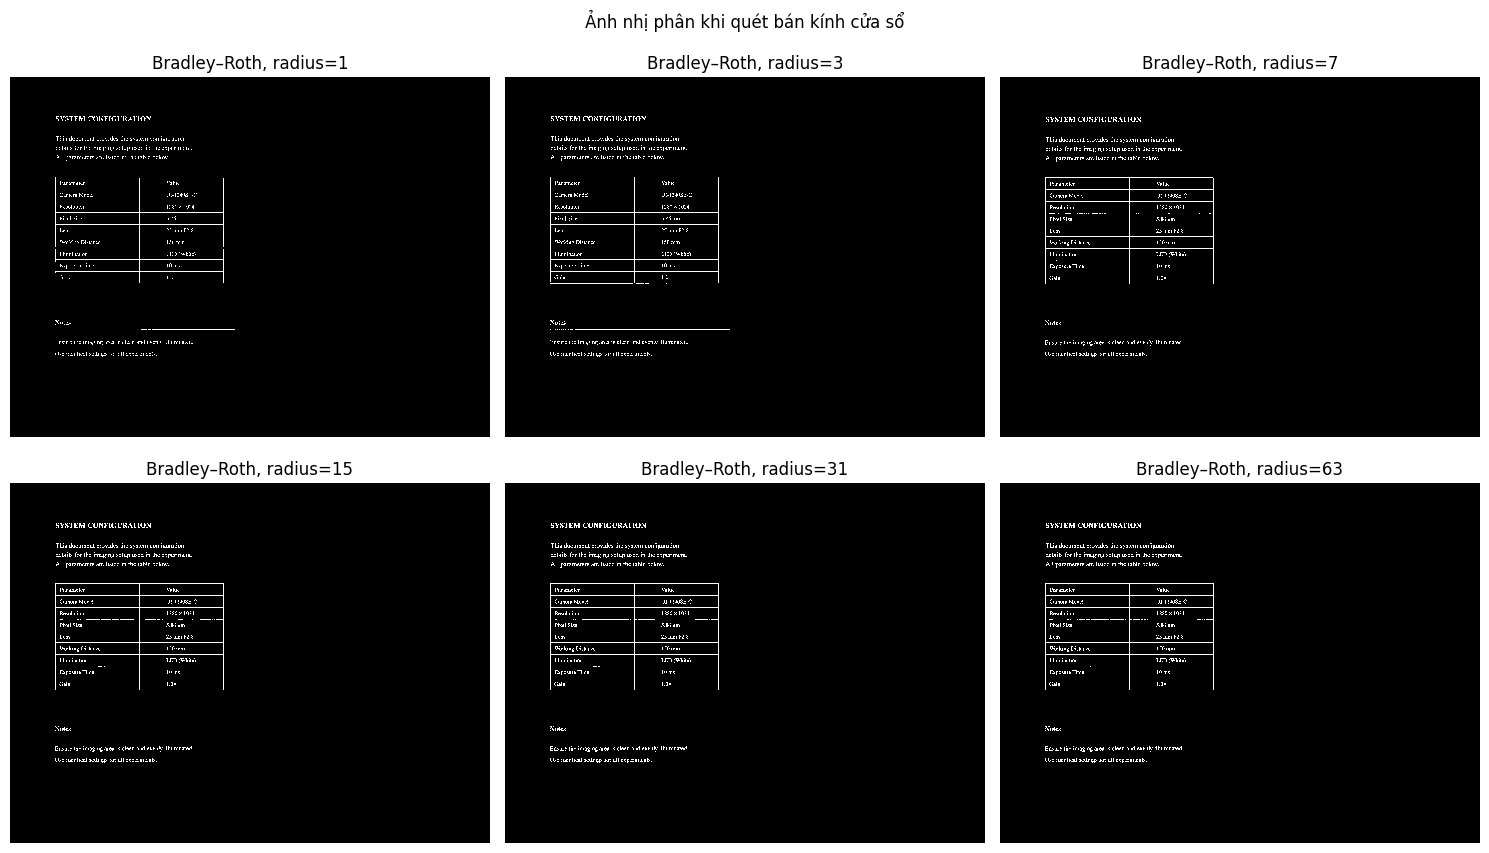

In [117]:
# Quét radius và hiển thị đúng ảnh nhị phân đầu ra.
radii = [1, 3, 7, 15, 31, 63]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, r in zip(axes.ravel(), radii):
    result = adaptive_threshold(
        img_gray,
        radius=r,
        method="bradley",
        t=0.15
    )
    ax.imshow(result, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Bradley–Roth, radius={r}")
    ax.axis("off")

fig.suptitle("Ảnh nhị phân khi quét bán kính cửa sổ")
fig.tight_layout()
plt.show()

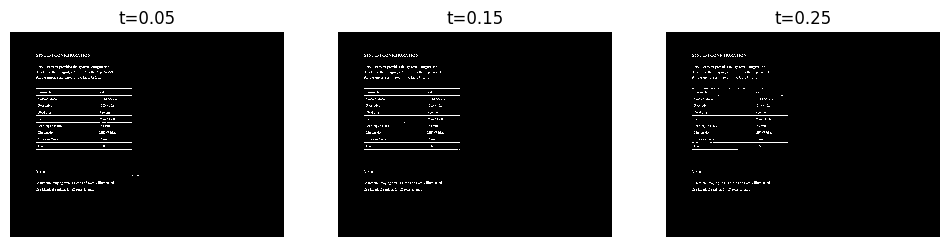

In [118]:
# TODO (a): quét t (hoặc k)
radius_fixed = 15

ts = [
    0.05,
    0.15,
    0.25
]

plt.figure(figsize=(12, 4))

for i, t in enumerate(ts):

    result = adaptive_threshold(
        img_gray,
        radius=radius_fixed,
        method="bradley",
        t=t
    )

    plt.subplot(
        1,
        3,
        i+1
    )

    plt.imshow(
        result,
        cmap="gray"
    )

    plt.title(
        f"t={t}"
    )

    plt.axis("off")

plt.show()

**Nhận xét (a):**

**Ảnh hưởng của `radius` trong Bradley–Roth:**
- Khi `radius` quá nhỏ, cửa sổ trượt nằm lọt thỏm trong nét mực, ngưỡng cục bộ bị kéo xuống sát với biến thiên độ sáng bên trong nét chữ làm phần lõi sáng hơn của nét dày bị gán thành nền, gây hiện tượng chữ bị rỗng ruột.
- Khi `radius` quá lớn, cửa sổ bao trùm vùng không gian quá rộng (chứa nhiều biến thiên ánh sáng), trung bình cục bộ bị cào bằng tiến gần về trung bình toàn ảnh. Thuật toán mất tính thích nghi và thoái hóa dần về ngưỡng toàn cục.
- Đại lượng quyết định vùng `radius` hợp lý phụ thuộc chủ yếu vào độ dày (kích thước) lớn nhất của nét chữ và mức độ thay đổi chiếu sáng của nền. Kích thước cửa sổ bắt buộc phải lớn hơn độ dày nét chữ để bao trọn được cả chữ và nền.
- Nếu chụp cùng cảnh ở độ phân giải gấp đôi, kích thước vật lý không đổi nhưng độ dày nét chữ (tính bằng số lượng pixel) sẽ tăng gấp đôi. Do đó, giá trị `radius` tốt nhất cũng phải tăng lên gấp đôi để duy trì tỷ lệ quét tương ứng.

**Ảnh hưởng của `t` trong Bradley–Roth (thí nghiệm giữ `radius=15`):**
- $T=m(1-t)$. Khi `t` tăng từ 0.05 lên 0.25, ngưỡng $T$ giảm.
- Vì foreground được định nghĩa bởi $I<T$, ngưỡng thấp hơn làm ít điểm ảnh được nhận là foreground hơn: nhiễu tối ở nền giảm nhưng nét chữ nhạt hoặc mảnh dễ bị mất.
- `t` nhỏ giữ được nhiều nét hơn nhưng cũng dễ nhận nhầm bóng nền. Giá trị phù hợp phải được chọn theo độ tương phản chữ–nền và mức không đều của ánh sáng.

### (b) So sánh với thuật toán đã học

Trên **cùng một ảnh**: ngưỡng cố định thủ công, **Otsu toàn cục**, **Bradley–Roth**, **Sauvola**.

⚠️ Ảnh dùng để so sánh **phải có ánh sáng không đều**. Trên ảnh chiếu sáng đều, cả bốn cho kết quả
gần như nhau và phép so sánh trở nên vô nghĩa.

Bổ sung **một ảnh có vùng nền phẳng rộng** để cho thấy chỗ Sauvola hơn hẳn Bradley–Roth.

## Khai báo sử dụng AI

Công cụ AI sử dụng:
ChatGPT

Mục đích sử dụng:
Hỗ trợ thiết kế thí nghiệm khảo sát so sánh giữa 4 phương pháp phân ngưỡng

Prompt đã sử dụng:
Trên cùng một ảnh có ánh sáng không đều, hãy so sánh 4 phương pháp phân ngưỡng: Manual Thresholding, Otsu toàn cục, Bradley–Roth và Sauvola; hiển thị kết quả và nhận xét sự khác biệt giữa các phương pháp, đồng thời bổ sung một ảnh có vùng nền phẳng rộng để thể hiện trường hợp Sauvola cho kết quả tốt hơn Bradley–Roth


Phần đã chỉnh sửa:
- Tự chọn ảnh thử nghiệm.
- Tự chạy code thí nghiệm.
- Tự đánh giá kết quả dựa trên ảnh thực tế.

Ngưỡng thủ công: 128
Ngưỡng Otsu: 118.00


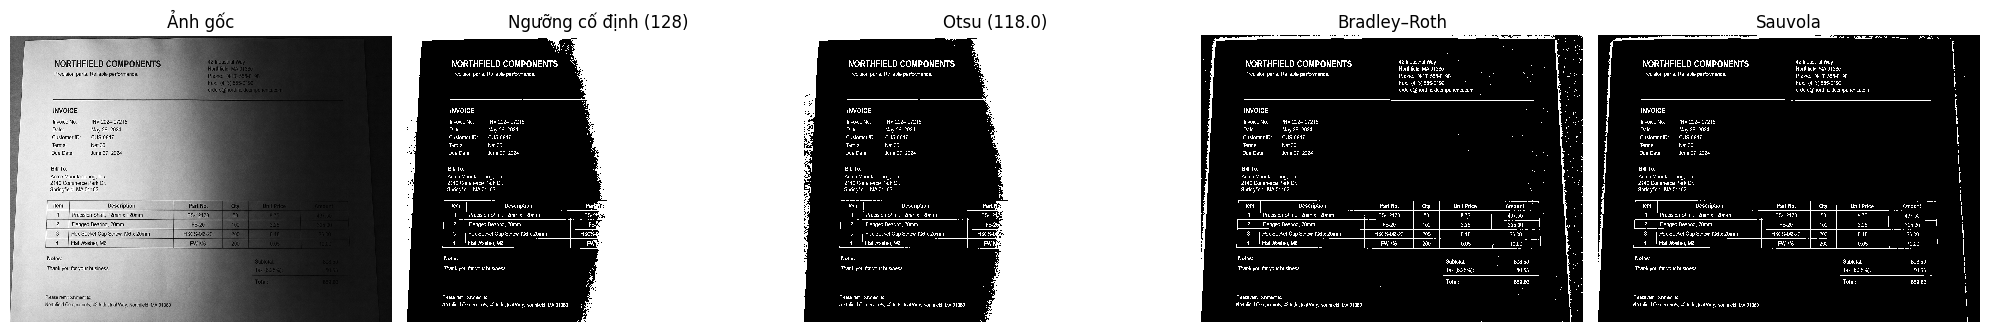

In [119]:
# Bốn phương pháp trên cùng ảnh; 255 luôn biểu diễn foreground tối.
def otsu_threshold_u8(image):
    """Ngưỡng Otsu toàn cục bằng NumPy; trả về ngưỡng và ảnh đảo nhãn."""
    histogram = np.bincount(np.asarray(image, dtype=np.uint8).ravel(), minlength=256)
    probabilities = histogram.astype(np.float64) / histogram.sum()
    levels = np.arange(256, dtype=np.float64)
    weight_background = np.cumsum(probabilities)
    mean_background_numerator = np.cumsum(probabilities * levels)
    mean_total = mean_background_numerator[-1]
    denominator = weight_background * (1.0 - weight_background)
    between_class_variance = np.zeros(256, dtype=np.float64)
    valid = denominator > 0
    between_class_variance[valid] = (
        (mean_total * weight_background[valid] - mean_background_numerator[valid]) ** 2
        / denominator[valid]
    )
    threshold = int(np.argmax(between_class_variance))
    binary = np.where(image < threshold, 255, 0).astype(np.uint8)
    return threshold, binary

img = IMAGES["uneven_light"]
manual_threshold = 128
manual = np.where(img < manual_threshold, 255, 0).astype(np.uint8)

otsu_threshold, otsu = otsu_threshold_u8(img)
bradley = adaptive_threshold(img, radius=15, method="bradley", t=0.15)
sauvola = adaptive_threshold(img, radius=15, method="sauvola", k=0.34, R=128.0)

print(f"Ngưỡng thủ công: {manual_threshold}")
print(f"Ngưỡng Otsu: {otsu_threshold:.2f}")

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
items = [
    (img, "Ảnh gốc"),
    (manual, f"Ngưỡng cố định ({manual_threshold})"),
    (otsu, f"Otsu ({otsu_threshold:.1f})"),
    (bradley, "Bradley–Roth"),
    (sauvola, "Sauvola"),
]
for ax, (image, title) in zip(axes, items):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

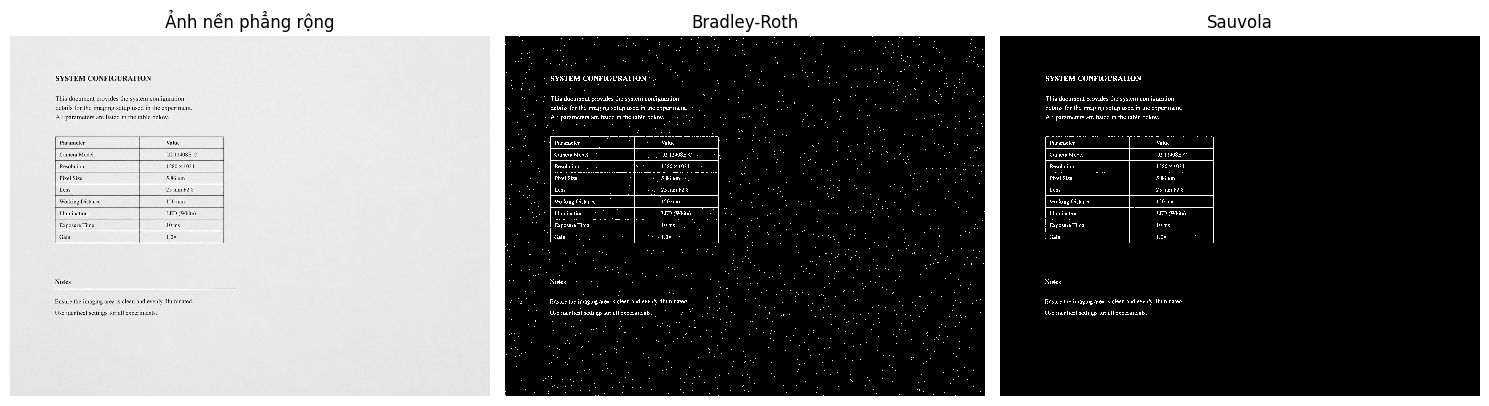

In [120]:
# TODO (b): ảnh có nền phẳng rộng — Sauvola vs Bradley-Roth
img_flat = IMAGES["flat_document"]

# Tạo ma trận nhiễu ngẫu nhiên với độ lệch chuẩn std=15
noise = np.random.normal(0, 15, img_flat.shape) 
# Cộng nhiễu vào ảnh, chốt chặn ở [0, 255] để không bị lỗi màu, rồi ép về uint8
img_flat_noisy = np.clip(img_flat.astype(np.float64) + noise, 0, 255).astype(np.uint8)

bradley_flat = adaptive_threshold(
    img_flat_noisy,
    radius=15,
    method="bradley",
    t=0.15
)

sauvola_flat = adaptive_threshold(
    img_flat_noisy,
    radius=15,
    method="sauvola",
    k=0.34,
    R=128.0
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_flat, cmap="gray")
axes[0].set_title("Ảnh nền phẳng rộng")
axes[0].axis("off")

axes[1].imshow(bradley_flat, cmap="gray")
axes[1].set_title("Bradley-Roth")
axes[1].axis("off")

axes[2].imshow(sauvola_flat, cmap="gray")
axes[2].set_title("Sauvola")
axes[2].axis("off")

plt.tight_layout()
plt.show()

**Nhận xét (b):**
- Ngưỡng cố định và Otsu bị sai lệch do chỉ dùng một mức ngưỡng duy nhất, không thể đáp ứng đồng thời cho cả vùng chói sáng và vùng sấp bóng. Ngược lại, Bradley-Roth và Sauvola khắc phục tốt nhược điểm này nhờ khai thác thông tin cục bộ, giúp linh hoạt điều chỉnh ngưỡng theo độ sáng của từng khu vực.

- Khác biệt cốt lõi là Bradley-Roth chỉ dựa trên độ sáng trung bình cục bộ ($m$), trong khi Sauvola tích hợp thêm cả độ lệch chuẩn ($s$). Nhờ biến số $s$ này, Sauvola có khả năng "đo lường" mức độ biến thiên của vùng lân cận để tự động tinh chỉnh ngưỡng khắt khe hay dễ dãi hơn.

- Tại các vùng nền phẳng, Bradley-Roth rất nhạy cảm với các dao động nhiễu nhỏ, dễ sinh ra nhiễu hạt lấm tấm. Ngược lại, việc tận dụng độ lệch chuẩn giúp Sauvola nhận diện được vùng nền không có cấu trúc chữ, từ đó tự động đẩy ngưỡng xuống thấp để khử nhiễu. Điều này minh chứng vì sao Sauvola mang lại nền đen sạch sẽ và vượt trội hơn hẳn so với Bradley-Roth.

### (c) Đường cong thời gian

Ba cách tính trung bình cục bộ, với `radius` $\in \{1, 2, 4, 8, 16, 32, 64\}$:

| Cách làm | Chi phí / điểm ảnh |
|---|---|
| Tích chập trực tiếp với nhân hộp *(dùng `convolve2d` của chính nhóm)* | $O(r^2)$ |
| Tích chập tách được (hai nhân 1 chiều) | $O(r)$ |
| Ảnh tích phân | $O(1)$ |

Vẽ ba đường trên cùng một trục, trục $y$ thang log.
Đường thứ ba phải **nằm ngang** — nếu không, gần như chắc chắn còn sót một vòng lặp Python
theo điểm ảnh ở đâu đó.

In [121]:
# TODO: dán hàm convolve2d của nhóm vào đây
def convolve2d(img, kernel, mode="same"):
    """Tích chập 2D tự cài (numpy thuần), zero-padding.

    img    : (H, W)
    kernel : (kh, kw)
    mode   : "same"  -> ra cùng kích thước img (mặc định)
             "valid" -> chỉ vùng phủ trọn, ra (H-kh+1, W-kw+1)
    """
    img = np.asarray(img, dtype=np.float64)
    ker = np.asarray(kernel, dtype=np.float64)
    kh, kw = ker.shape
    kf = ker[::-1, ::-1]                      

    if mode == "same":
        ph, pw = kh // 2, kw // 2
        padded = np.pad(img, ((ph, ph), (pw, pw)), mode="constant")
        out_h, out_w = img.shape
    elif mode == "valid":
        padded = img
        out_h, out_w = img.shape[0] - kh + 1, img.shape[1] - kw + 1
    else:
        raise ValueError("mode phải là 'same' hoặc 'valid'")

    out = np.zeros((out_h, out_w), dtype=np.float64)
    for i in range(kh):
        for j in range(kw):
            out += kf[i, j] * padded[i:i + out_h, j:j + out_w]
    return out

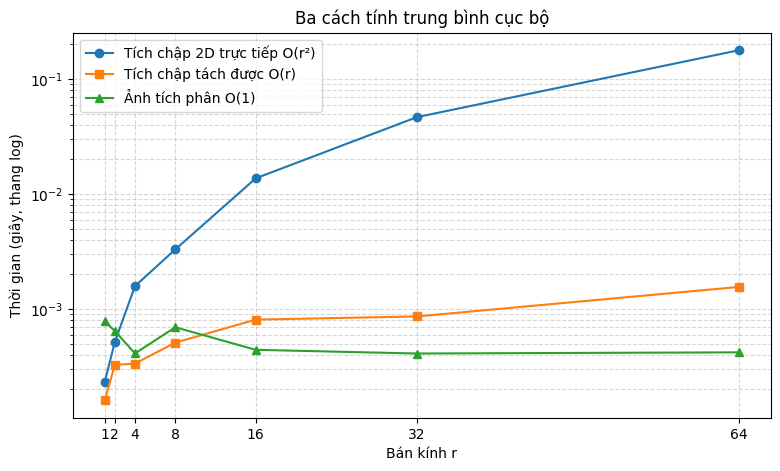

In [122]:
import time
import matplotlib.pyplot as plt
import numpy as np


def box_mean_separable(img, radius):
    """Nhân hộp tách được: hai lượt tích chập 1D tự cài, zero-padding."""
    x = np.asarray(img, dtype=np.float64)
    k = 2 * radius + 1

    padded_x = np.pad(x, ((0, 0), (radius, radius)), mode="constant")
    horizontal = np.zeros_like(x, dtype=np.float64)
    for j in range(k):
        horizontal += padded_x[:, j:j + x.shape[1]]

    padded_y = np.pad(horizontal, ((radius, radius), (0, 0)), mode="constant")
    result = np.zeros_like(x, dtype=np.float64)
    for i in range(k):
        result += padded_y[i:i + x.shape[0], :]
    return result / (k * k)


def box_mean_integral(S, radius):
    """Trung bình hộp cho toàn ảnh bằng bốn lần truy cập ảnh tích phân."""
    h, w = S.shape[0] - 1, S.shape[1] - 1
    yy, xx = np.indices((h, w))
    y1 = np.maximum(0, yy - radius)
    x1 = np.maximum(0, xx - radius)
    y2 = np.minimum(h - 1, yy + radius)
    x2 = np.minimum(w - 1, xx + radius)
    # Chia cho toàn bộ diện tích nhân để tương đương zero-padding.
    return box_sum(S, y1, x1, y2, x2) / float((2 * radius + 1) ** 2)


RADII = [1, 2, 4, 8, 16, 32, 64]
rng = np.random.default_rng(0)
test_img = rng.integers(0, 256, size=(128, 128), dtype=np.uint8)
S_test = integral_image(test_img)

t_conv2d, t_separable, t_integral = [], [], []
for r in RADII:
    kernel = np.ones((2 * r + 1, 2 * r + 1), dtype=np.float64)
    kernel /= kernel.size

    start = time.perf_counter()
    direct = convolve2d(test_img, kernel, mode="same")
    t_conv2d.append(time.perf_counter() - start)

    start = time.perf_counter()
    separable = box_mean_separable(test_img, r)
    t_separable.append(time.perf_counter() - start)

    start = time.perf_counter()
    integral = box_mean_integral(S_test, r)
    t_integral.append(time.perf_counter() - start)

    assert np.allclose(direct, separable)
    assert np.allclose(direct, integral)

plt.figure(figsize=(9, 5))
plt.plot(RADII, t_conv2d, "o-", label="Tích chập 2D trực tiếp O(r²)")
plt.plot(RADII, t_separable, "s-", label="Tích chập tách được O(r)")
plt.plot(RADII, t_integral, "^-", label="Ảnh tích phân O(1)")
plt.yscale("log")
plt.xlabel("Bán kính r")
plt.ylabel("Thời gian (giây, thang log)")
plt.title("Ba cách tính trung bình cục bộ")
plt.xticks(RADII)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

### Nhận xét kết quả benchmark

1. **Tích chập 2D trực tiếp:** dùng `convolve2d` tự cài với nhân hộp $(2r+1)\times(2r+1)$, nên số lượt cộng mảng tăng theo $O(r^2)$ và thời gian tăng nhanh theo bán kính.
2. **Tích chập tách được:** thực hiện hai lượt với nhân 1 chiều dài $2r+1$, nên chi phí tăng theo $O(r)$.
3. **Ảnh tích phân:** `S_test` được dựng một lần; bốn mảng tọa độ góc được đưa vào `box_sum` theo cách vector hóa. Mỗi tổng vùng cần bốn lần truy cập và ba phép cộng/trừ, không có vòng lặp Python theo điểm ảnh, nên thời gian truy vấn gần như không phụ thuộc `r` (dao động nhỏ là nhiễu đo thời gian).

Ba kết quả được kiểm tra bằng `np.allclose` ở mọi bán kính để bảo đảm benchmark đo ba cách cài đặt của cùng một phép lọc hộp với zero-padding.

---
---
# 3. Kỹ thuật 3 — Biến đổi Hough đa tỉ lệ

Lý thuyết: xem mục 4 của tài liệu bổ trợ.

Phần này sử dụng hàm `convolve2d` do nhóm tự viết, đã đặt ngay trước ô benchmark để cả Kỹ thuật 2 và Kỹ thuật 3 dùng chung một định nghĩa.

## 3.1 Cài đặt — ❌ KHÔNG dùng AI

Thư viện được phép: `numpy`, `convolve2d` của chính nhóm, `matplotlib`.

Bị cấm: `cv2.HoughLines`, `cv2.HoughLinesP`, `skimage.transform.hough_line`,
`skimage.transform.hough_line_peaks`, `scipy.signal.find_peaks` (áp cho mảng 2 chiều),
`scipy.ndimage.maximum_filter`.

In [123]:
def hough_accumulate(edges, theta_range, rho_range, n_theta, n_rho,
                     grad_dir=None, delta_deg=None):
    """Bỏ phiếu vào mảng tích lũy Hough.

    edges       : (H, W) bool hoặc uint8 — bản đồ biên.
    theta_range : (theta_min, theta_max) radian.
    rho_range   : (rho_min, rho_max).
    grad_dir    : (H, W) float — hướng gradient tại mỗi điểm, radian, đã chuẩn hóa về [0, pi).
                  Nếu khác None, mỗi điểm chỉ bỏ phiếu trong dải +/- delta_deg quanh hướng đó.

    Trả về      : (A, thetas, rhos)
    """
    edges = np.asarray(edges)
    ys, xs = np.nonzero(edges)                       # toạ độ điểm biên

    theta_min, theta_max = theta_range
    rho_min, rho_max = rho_range
    thetas = np.linspace(theta_min, theta_max, n_theta, endpoint=False)
    rhos   = np.linspace(rho_min,   rho_max,   n_rho,   endpoint=False)

    A = np.zeros((n_rho, n_theta), dtype=np.int64)
    if xs.size == 0:
        return A, thetas, rhos

    cos_t = np.cos(thetas)
    sin_t = np.sin(thetas)
    drho  = (rho_max - rho_min) / n_rho              # bề rộng 1 ô rho

    if grad_dir is None:
        # rho[p, k] = x_p*cos_k + y_p*sin_k, bỏ phiếu toàn dải theta
        rho_vals  = np.outer(xs, cos_t) + np.outer(ys, sin_t)   # (P, n_theta)
        rho_idx   = np.round((rho_vals - rho_min) / drho).astype(int)
        theta_idx = np.broadcast_to(np.arange(n_theta), rho_idx.shape)
        valid = (rho_idx >= 0) & (rho_idx < n_rho)
        np.add.at(A, (rho_idx[valid].ravel(), theta_idx[valid].ravel()), 1)
    else:
        # chỉ vote trong +/- delta_deg quanh hướng gradient từng điểm
        delta = np.deg2rad(delta_deg)
        gd = grad_dir[ys, xs]
        for p in range(xs.size):
            d = np.abs(thetas - gd[p])
            d = np.minimum(d, np.pi - d)             # khoảng cách góc trên [0, pi)
            sel = d <= delta
            if not np.any(sel):
                continue
            rho_vals = xs[p] * cos_t[sel] + ys[p] * sin_t[sel]
            rho_idx  = np.round((rho_vals - rho_min) / drho).astype(int)
            ti = np.nonzero(sel)[0]
            ok = (rho_idx >= 0) & (rho_idx < n_rho)
            np.add.at(A, (rho_idx[ok], ti[ok]), 1)

    return A, thetas, rhos

In [124]:
def find_peaks(A, n_peaks, nms_radius=3, smooth_sigma=1.0):
    """Tìm đỉnh trong mảng tích lũy.

    Ba bước: làm mượt A bằng convolve2d của chính nhóm -> triệt phi cực đại trong bán kính
    nms_radius -> lấy n_peaks đỉnh cao nhất.

    Trả về: list [(i_rho, i_theta, votes), ...] sắp giảm dần theo votes.
    """
    A = np.asarray(A, dtype=np.float64)

    # 1) làm mượt bằng convolve2d CỦA NHÓM (nhân Gaussian dựng tại chỗ)
    if smooth_sigma and smooth_sigma > 0:
        r = max(1, int(round(3 * smooth_sigma)))
        ax = np.arange(-r, r + 1)
        g = np.exp(-(ax ** 2) / (2 * smooth_sigma ** 2))
        kernel = np.outer(g, g)
        kernel /= kernel.sum()
        As = convolve2d(A, kernel)
    else:
        As = A.copy()

    H, W = As.shape
    work = As.copy()
    peaks = []
    for _ in range(n_peaks):
        # đỉnh cao nhất còn lại
        i, j = np.unravel_index(int(np.argmax(work)), work.shape)
        if not np.isfinite(work[i, j]) or work[i, j] <= 0:
            break
        peaks.append((int(i), int(j), int(A[i, j])))   # votes lấy từ A gốc
        # 2) triệt phi cực đại quanh đỉnh
        i1, i2 = max(0, i - nms_radius), min(H, i + nms_radius + 1)
        j1, j2 = max(0, j - nms_radius), min(W, j + nms_radius + 1)
        work[i1:i2, j1:j2] = -np.inf

    peaks.sort(key=lambda p: p[2], reverse=True)        # 3) giảm dần theo votes
    return peaks

In [125]:
def _edge_voters(edges, rho, theta, rho_step):
    """Giữ đúng các điểm biên đã bỏ phiếu cho ô (rho, theta)."""
    ys, xs = np.nonzero(edges)
    selected = np.zeros_like(edges, dtype=bool)
    if xs.size == 0:
        return selected
    rho_values = xs * np.cos(theta) + ys * np.sin(theta)
    keep = np.abs(rho_values - rho) <= rho_step / 2.0
    selected[ys[keep], xs[keep]] = True
    return selected


def _local_hough(edges, center_rho, center_theta, rho_step, theta_step,
                 refine_factor, grad_dir=None, delta_deg=None):
    """Accumulator mịn trong cửa sổ quanh peak; theta được phép vượt biên."""
    n = 2 * refine_factor + 1
    new_rho_step = rho_step / refine_factor
    new_theta_step = theta_step / refine_factor
    rhos = center_rho + np.arange(-refine_factor, refine_factor + 1) * new_rho_step
    thetas = center_theta + np.arange(-refine_factor, refine_factor + 1) * new_theta_step

    ys, xs = np.nonzero(edges)
    A = np.zeros((n, n), dtype=np.int64)
    if xs.size == 0:
        return A, thetas, rhos, new_theta_step, new_rho_step

    for j, theta in enumerate(thetas):
        if grad_dir is not None:
            canonical_theta = theta % np.pi
            gd = grad_dir[ys, xs] % np.pi
            distance = np.abs(gd - canonical_theta)
            distance = np.minimum(distance, np.pi - distance)
            allowed = distance <= np.deg2rad(delta_deg)
        else:
            allowed = np.ones(xs.size, dtype=bool)
        values = xs[allowed] * np.cos(theta) + ys[allowed] * np.sin(theta)
        indices = np.rint((values - rhos[0]) / new_rho_step).astype(int)
        valid = (indices >= 0) & (indices < n)
        np.add.at(A[:, j], indices[valid], 1)
    return A, thetas, rhos, new_theta_step, new_rho_step


def _canonical_line(rho, theta):
    turns = int(np.floor(theta / np.pi))
    theta = theta - turns * np.pi
    if turns % 2:
        rho = -rho
    return float(rho), float(theta)


def hough_multiscale(edges, grad_dir=None, n_peaks=8, n_levels=2, refine_factor=8,
                     n_theta0=180, n_rho0=None, delta_deg=None,
                     return_details=False):
    """Hough thô-đến-mịn; mỗi tầng chỉ dùng lại voter của ô cha.

    Với ``return_details=True``, trả thêm accumulator gắn với peak cuối
    để các chỉ số chất lượng không phải lấy nhầm accumulator tầng thô.
    """
    if n_levels < 1 or refine_factor <= 1 or n_theta0 < 2 or n_peaks < 1:
        raise ValueError("Tham số Hough đa tỉ lệ không hợp lệ")
    if n_rho0 is None:
        n_rho0 = n_theta0
    if n_rho0 < 2:
        raise ValueError("n_rho0 phải >= 2")

    edges = np.asarray(edges, dtype=bool)
    h, w = edges.shape
    rho_limit = float(np.hypot(h, w))
    theta_step = np.pi / n_theta0
    rho_step = 2.0 * rho_limit / n_rho0

    A0, thetas0, rhos0 = hough_accumulate(
        edges, (0.0, np.pi), (-rho_limit, rho_limit), n_theta0, n_rho0,
        grad_dir=grad_dir, delta_deg=delta_deg
    )
    coarse_peaks = find_peaks(A0, n_peaks)
    candidates = []
    for i_rho, i_theta, votes in coarse_peaks:
        rho = float(rhos0[i_rho])
        theta = float(thetas0[i_theta])
        voters = _edge_voters(edges, rho, theta, rho_step)
        candidates.append({
            "rho": rho, "theta": theta, "votes": int(votes),
            "voters": voters, "accumulator": A0
        })

    for _ in range(1, n_levels):
        refined = []
        for candidate in candidates:
            # Điểm quan trọng của đặc tả: không truyền toàn bộ edges vào tầng sau.
            parent_voters = candidate["voters"]
            A_local, local_thetas, local_rhos, next_theta_step, next_rho_step = _local_hough(
                parent_voters, candidate["rho"], candidate["theta"],
                rho_step, theta_step, refine_factor,
                grad_dir=grad_dir, delta_deg=delta_deg
            )
            if not np.any(A_local):
                continue
            i_rho, i_theta = np.unravel_index(np.argmax(A_local), A_local.shape)
            rho = float(local_rhos[i_rho])
            theta = float(local_thetas[i_theta])
            voters = _edge_voters(parent_voters, rho, theta, next_rho_step)
            refined.append({
                "rho": rho, "theta": theta, "votes": int(A_local[i_rho, i_theta]),
                "voters": voters, "accumulator": A_local
            })
        candidates = refined
        theta_step /= refine_factor
        rho_step /= refine_factor
        if not candidates:
            break

    candidates.sort(key=lambda item: item["votes"], reverse=True)
    results = []
    details = []
    for item in candidates:
        rho, theta = _canonical_line(item["rho"], item["theta"])
        results.append((rho, theta, item["votes"]))
        details.append({
            "rho": rho,
            "theta": theta,
            "votes": item["votes"],
            "accumulator": item["accumulator"],
            "n_voters": int(np.count_nonzero(item["voters"]))
        })
    return (results, details) if return_details else results

### Tiện ích: sinh ảnh tổng hợp có đáp án đúng *(cung cấp sẵn)*

Kỹ thuật này là kỹ thuật **duy nhất** trong ba kỹ thuật cho phép tạo ảnh có đáp án đúng tuyệt đối.
Hãy tận dụng: phần lớn thí nghiệm nên chạy trên ảnh tổng hợp trước, rồi mới kiểm lại trên ảnh thật.

In [126]:
def draw_line(canvas, rho, theta_deg, length=None, value=255, thickness=1):
    """Vẽ một đoạn thẳng có (rho, theta) đã biết lên canvas, tính từ gốc (0, 0) ở góc trên-trái.

    rho, theta_deg : tham số đường thẳng, theo đúng quy ước rho = x cos(theta) + y sin(theta).
    length         : độ dài đoạn (điểm ảnh). None = kéo hết ảnh.

    Trả về canvas (sửa tại chỗ).
    """
    H, W = canvas.shape
    th = np.deg2rad(theta_deg)
    ct, st = np.cos(th), np.sin(th)
    x0, y0 = rho * ct, rho * st          # chân đường vuông góc từ gốc
    dx, dy = -st, ct                     # vectơ chỉ phương
    L = length if length is not None else 2 * int(np.hypot(H, W))
    t = np.arange(-L / 2, L / 2, 0.5)
    xs = np.round(x0 + t * dx).astype(int)
    ys = np.round(y0 + t * dy).astype(int)
    for oy in range(-(thickness // 2), thickness // 2 + 1):
        for ox in range(-(thickness // 2), thickness // 2 + 1):
            X, Y = xs + ox, ys + oy
            m = (X >= 0) & (X < W) & (Y >= 0) & (Y < H)
            canvas[Y[m], X[m]] = value
    return canvas


def synthetic_lines(shape, lines, noise_frac=0.0, seed=0):
    """Ảnh nhị phân chứa các đoạn thẳng đã biết.

    lines : list các dict {"rho": .., "theta_deg": .., "length": .. (tùy chọn)}
    noise_frac : tỉ lệ điểm biên nhiễu thêm vào, tính trên số điểm biên thật.

    Trả về (img, lines) — lines chính là đáp án đúng.
    """
    rng = np.random.default_rng(seed)
    img = np.zeros(shape, np.uint8)
    for ln in lines:
        draw_line(img, ln["rho"], ln["theta_deg"], ln.get("length"))
    if noise_frac > 0:
        n = int(noise_frac * np.count_nonzero(img))
        ys = rng.integers(0, shape[0], n)
        xs = rng.integers(0, shape[1], n)
        img[ys, xs] = 255
    return img, lines

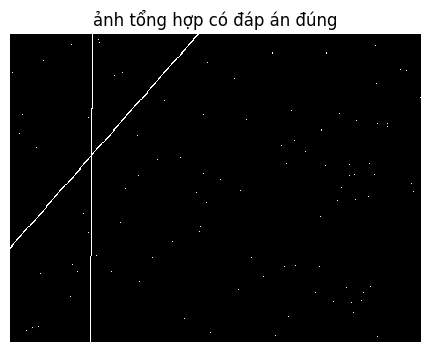

In [127]:
# Ví dụ dùng thử tiện ích (không phải bài làm):
demo, gt = synthetic_lines((300, 400), [
    {"rho": 137.0, "theta_deg": 41.3},
    {"rho":  80.0, "theta_deg":  0.4},   # gần thẳng đứng — bẫy quấn vòng
], noise_frac=0.15, seed=1)
plt.imshow(demo); plt.title("ảnh tổng hợp có đáp án đúng"); plt.axis("off"); plt.show()

## 3.2 Thí nghiệm minh họa — ✅ được dùng AI *(nhớ khai báo prompt)*

### (a) Ảnh hưởng của tham số

Quét $\Delta\theta$ và $\Delta\rho$ qua **ít nhất bốn giá trị**.
Trình bày **cả mảng tích lũy** (dưới dạng ảnh) **và** các đường thẳng phát hiện được —
mảng tích lũy là nơi hiện tượng **vỡ phiếu** nhìn thấy rõ nhất.

Sau đó quét số tầng $n$ và hệ số tinh chỉnh $r$, vẽ **sai số góc theo $n$**.

## Khai báo sử dụng AI

Công cụ AI sử dụng: Claude

Mục đích sử dụng:
Hỗ trợ dựng khung thí nghiệm khảo sát ảnh hưởng của độ phân giải
Δθ và Δρ trong biến đổi Hough, đề xuất cách trình bày đồng thời mảng
tích lũy (accumulator) và các đường thẳng phát hiện được, cũng như
gợi ý cách quan sát hiện tượng vỡ phiếu trong mảng tích lũy.

Prompt đã sử dụng:

Bài toán biến đổi Hough sử dụng hàm hough_accumulate và find_peaks,
hãy giúp tôi dựng khung thí nghiệm khảo sát ảnh hưởng của độ phân
giải Δθ và Δρ. Yêu cầu quét mỗi tham số ít nhất 4 giá trị, hiển thị
đồng thời mảng tích lũy dưới dạng ảnh và các đường thẳng phát hiện
được chồng lên ảnh gốc, sao cho thấy được hiện tượng vỡ phiếu. Hãy
gợi ý cách phân tích kết quả.

Phần đã chỉnh sửa:
- Tự chọn ảnh tổng hợp có đáp án đúng để thử nghiệm.
- Tự chọn các mức n_theta và n_rho tương ứng với Δθ, Δρ.
- Tự chạy code thí nghiệm.
- Tự đánh giá kết quả và viết nhận xét dựa trên ảnh và số liệu thực tế.

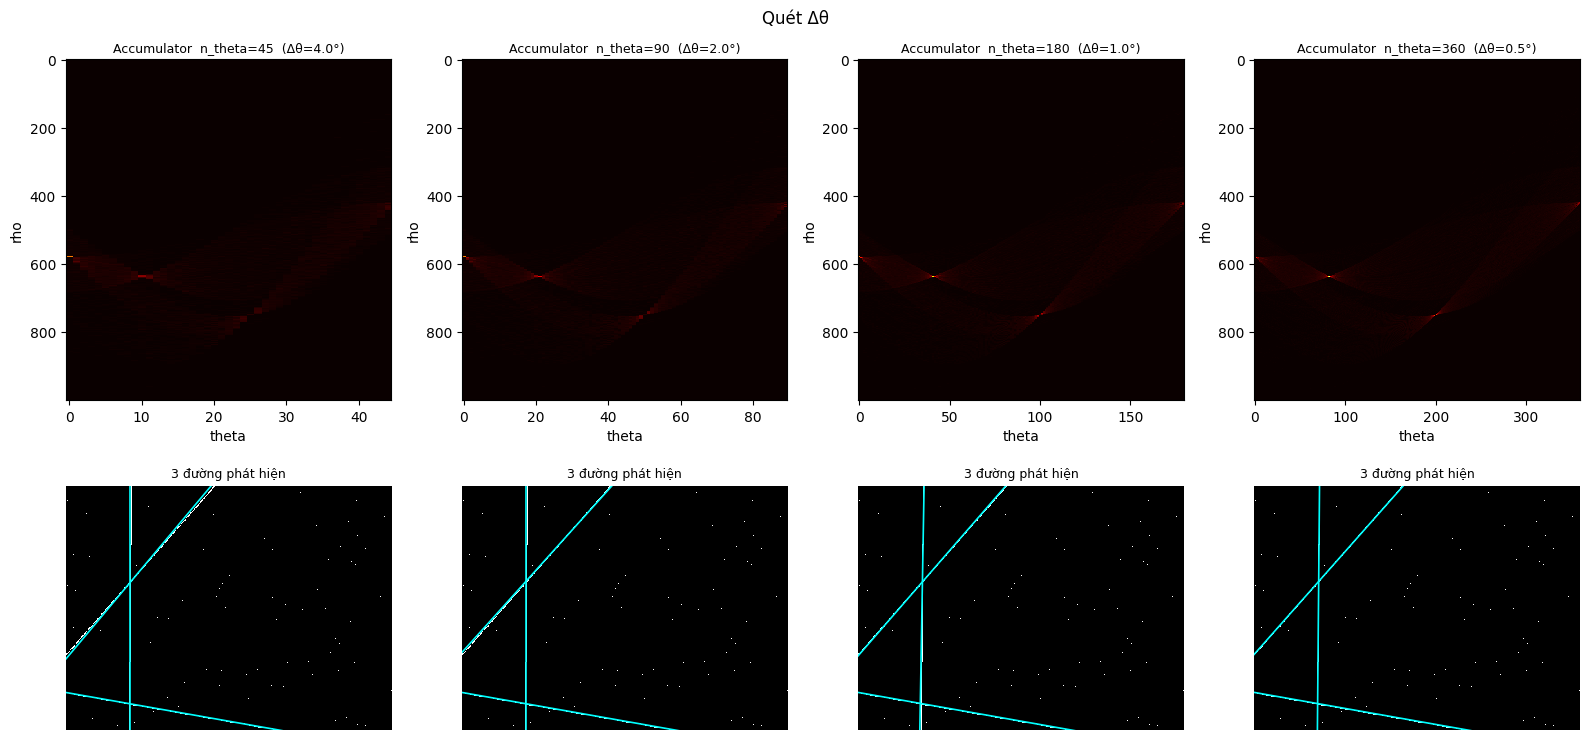

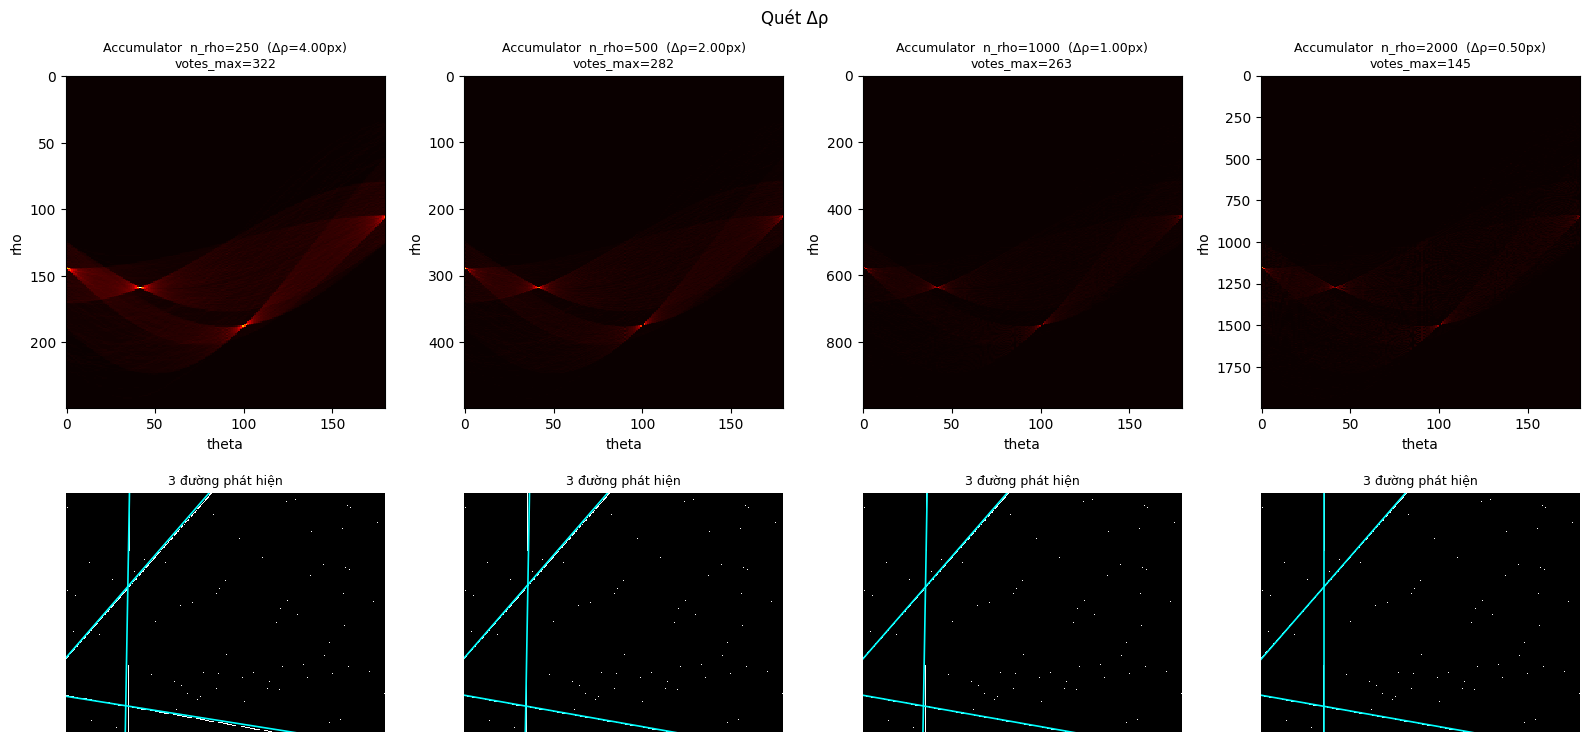

In [128]:
# TODO (a): quét độ phân giải, hiển thị mảng tích lũy + đường phát hiện
def _ve_duong(ax, rho, theta, H, W, color="cyan"):
    """Vẽ 1 đường (rho, theta[rad]) chồng lên ảnh ở ax."""
    ct, st = np.cos(theta), np.sin(theta)
    x0, y0 = rho * ct, rho * st
    dx, dy = -st, ct
    L = 2 * np.hypot(H, W)
    ax.plot([x0 - L*dx, x0 + L*dx], [y0 - L*dy, y0 + L*dy], color=color, lw=1.2)

# Ảnh tổng hợp có đáp án đúng
H, W = 300, 400
GT = [
    {"rho": 137.0, "theta_deg": 41.3},
    {"rho":  80.0, "theta_deg":  0.4},    # gần thẳng đứng
    {"rho": 250.0, "theta_deg": 100.0},
]
img_syn, _ = synthetic_lines((H, W), GT, noise_frac=0.12, seed=1)
diag = np.hypot(H, W)
theta_range = (0.0, np.pi)
rho_range   = (-diag, diag)

# ---------- Quét Δθ (đổi n_theta; Δθ = 180°/n_theta) ----------
N_THETA = [45, 90, 180, 360]              # Δθ = 4.0, 2.0, 1.0, 0.5 độ
n_rho_fixed = 2 * int(diag)

fig, axes = plt.subplots(2, len(N_THETA), figsize=(4*len(N_THETA), 8))
for c, nt in enumerate(N_THETA):
    A, thetas, rhos = hough_accumulate(img_syn, theta_range, rho_range, nt, n_rho_fixed)
    peaks = find_peaks(A, n_peaks=3, nms_radius=3)

    axes[0, c].imshow(A, cmap="hot", aspect="auto")
    axes[0, c].set_title(f"Accumulator  n_theta={nt}  (Δθ={180/nt:.1f}°)", fontsize=9)
    axes[0, c].set_xlabel("theta"); axes[0, c].set_ylabel("rho")

    axes[1, c].imshow(img_syn, cmap="gray")
    for ir, it, v in peaks:
        _ve_duong(axes[1, c], rhos[ir], thetas[it], H, W)
    axes[1, c].set_title(f"{len(peaks)} đường phát hiện", fontsize=9)
    axes[1, c].set_xlim(0, W); axes[1, c].set_ylim(H, 0); axes[1, c].axis("off")
fig.suptitle("Quét Δθ", fontsize=12); fig.tight_layout(); plt.show()

# ---------- Quét Δρ (đổi n_rho; Δρ = 2·diag/n_rho) ----------
N_RHO = [int(diag//2), int(diag), 2*int(diag), 4*int(diag)]
n_theta_fixed = 180

fig, axes = plt.subplots(2, len(N_RHO), figsize=(4*len(N_RHO), 8))
for c, nr in enumerate(N_RHO):
    A, thetas, rhos = hough_accumulate(img_syn, theta_range, rho_range, n_theta_fixed, nr)
    peaks = find_peaks(A, n_peaks=3, nms_radius=3)

    axes[0, c].imshow(A, cmap="hot", aspect="auto")
    axes[0, c].set_title(f"Accumulator  n_rho={nr}  (Δρ={2*diag/nr:.2f}px)"
                         f"\nvotes_max={peaks[0][2]}", fontsize=9)
    axes[0, c].set_xlabel("theta"); axes[0, c].set_ylabel("rho")

    axes[1, c].imshow(img_syn, cmap="gray")
    for ir, it, v in peaks:
        _ve_duong(axes[1, c], rhos[ir], thetas[it], H, W)
    axes[1, c].set_title(f"{len(peaks)} đường phát hiện", fontsize=9)
    axes[1, c].set_xlim(0, W); axes[1, c].set_ylim(H, 0); axes[1, c].axis("off")
fig.suptitle("Quét Δρ", fontsize=12); fig.tight_layout(); plt.show()

### Có dùng AI hỗ trợ

**Công cụ:** ChatGPT (GPT-5.6 Luna)

**Mục đích:** Dựng khung thí nghiệm khảo sát ảnh hưởng của số tầng `n_levels` và `refine_factor` trong Hough đa tỉ lệ, tính sai số góc so với ground truth và vẽ sai số góc theo số tầng.

**Prompt đã sử dụng:**

Hãy giúp tôi dựng một thí nghiệm Python đơn giản cho hàm hough_multiscale đã có sẵn, sử dụng ảnh tổng hợp có ground truth. Quét n_levels qua ít nhất 4 giá trị và refine_factor qua ít nhất 3 giá trị, tính sai số góc của peak phát hiện được so với góc ground truth, sau đó vẽ sai số góc theo n_levels.

**Phần đã chỉnh sửa:**
- Tự chọn các giá trị `n_levels` và `refine_factor`.
- Tự chọn ảnh tổng hợp và ground truth.
- Tự chạy code và đánh giá kết quả thực tế.

Sai số góc theo n_levels:
refine_factor = 2
  n_levels = 1 : 0.30000000000000043 deg
  n_levels = 2 : 0.30000000000000043 deg
  n_levels = 3 : 0.2000000000000003 deg
  n_levels = 4 : 0.2000000000000003 deg
refine_factor = 4
  n_levels = 1 : 0.30000000000000043 deg
  n_levels = 2 : 0.05000000000000325 deg
  n_levels = 3 : 0.012499999999999222 deg
  n_levels = 4 : 0.012499999999999222 deg
refine_factor = 8
  n_levels = 1 : 0.30000000000000043 deg
  n_levels = 2 : 0.17500000000000185 deg
  n_levels = 3 : 0.11249999999999936 deg
  n_levels = 4 : 0.11445312499999646 deg
refine_factor = 16
  n_levels = 1 : 0.30000000000000043 deg
  n_levels = 2 : 0.11249999999999936 deg
  n_levels = 3 : 0.11640624999999992 deg
  n_levels = 4 : 0.1142089843749984 deg


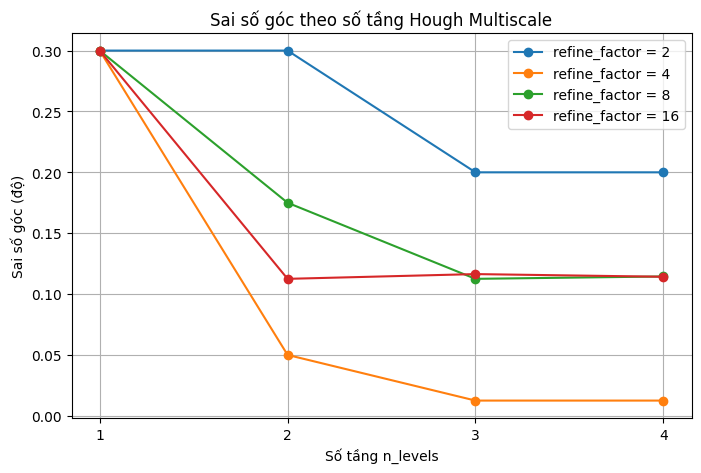

In [129]:
# TODO (a): sai số góc theo số tầng n
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. Tạo một ảnh tổng hợp có đáp án đúng
# =========================================================

H = 300
W = 400

ground_truth = [
    {
        "rho": 137.0,
        "theta_deg": 41.3
    }
]

img_test, gt = synthetic_lines(
    (H, W),
    ground_truth,
    noise_frac=0.12,
    seed=10
)


# =========================================================
# 2. Hàm tính sai số góc
# =========================================================

def angle_error_degree(theta_hat, theta_true):

    turns = int(
        np.round(
            (theta_hat - theta_true) / np.pi
        )
    )

    theta_aligned = (
        theta_hat
        - turns * np.pi
    )

    error = abs(
        np.rad2deg(
            theta_aligned - theta_true
        )
    )

    return error


# Góc đúng
theta_true = np.deg2rad(
    ground_truth[0]["theta_deg"]
)


# =========================================================
# 3. Các giá trị cần khảo sát
# =========================================================

n_levels_values = [1, 2, 3, 4]

refine_factor_values = [2, 4, 8, 16]


# Lưu kết quả
all_errors = {}


# =========================================================
# 4. Quét từng refine_factor
# =========================================================

for refine_factor in refine_factor_values:

    errors = []

    for n_levels in n_levels_values:

        results = hough_multiscale(
            img_test > 0,
            n_peaks=1,
            n_levels=n_levels,
            refine_factor=refine_factor,
            n_theta0=180,
            n_rho0=180
        )

        if len(results) == 0:

            error = np.nan

        else:

            rho_hat = results[0][0]
            theta_hat = results[0][1]

            error = angle_error_degree(
                theta_hat,
                theta_true
            )

        errors.append(error)

    all_errors[refine_factor] = errors


# =========================================================
# 5. In kết quả
# =========================================================

print("Sai số góc theo n_levels:")

for refine_factor in refine_factor_values:

    print(
        "refine_factor =",
        refine_factor
    )

    for i in range(len(n_levels_values)):

        print(
            "  n_levels =",
            n_levels_values[i],
            ":",
            all_errors[refine_factor][i],
            "deg"
        )


# =========================================================
# 6. Vẽ biểu đồ
# =========================================================

plt.figure(
    figsize=(8, 5)
)

for refine_factor in refine_factor_values:

    plt.plot(
        n_levels_values,
        all_errors[refine_factor],
        marker="o",
        label="refine_factor = " + str(refine_factor)
    )

plt.xlabel("Số tầng n_levels")
plt.ylabel("Sai số góc (độ)")
plt.title(
    "Sai số góc theo số tầng Hough Multiscale"
)

plt.xticks(n_levels_values)
plt.grid(True)
plt.legend()
plt.show()

**Nhận xét (a):**

Kết quả cho thấy số tầng `n_levels` và hệ số tinh chỉnh `refine_factor` đều ảnh hưởng rõ rệt đến sai số góc. Với `refine_factor = 2`, sai số chỉ giảm từ 0.30° xuống 0.20° rồi giữ nguyên, cho thấy mức chia nhỏ còn hạn chế.

Trường hợp `refine_factor = 4` cho kết quả ổn định và tốt nhất: sai số giảm từ 0.30° ở tầng 1 xuống 0.05° ở tầng 2 và 0.0125° ở tầng 3, sau đó giữ ở 0.0125° tại tầng 4. Như vậy các tầng đầu cải thiện rõ độ chính xác, nhưng thêm tầng không bảo đảm tiếp tục giảm sai số.

Với `refine_factor = 8` và `16`, sai số giảm sau tinh chỉnh đầu tiên nhưng dừng quanh 0.11° và dao động nhẹ ở các tầng sau. Điều này cho thấy tăng hệ số tinh chỉnh không bảo đảm sai số luôn giảm; peak tốt có thể không nằm đúng tâm cửa sổ tinh chỉnh kế tiếp.

Với bộ ảnh và tham số đang thử nghiệm, `refine_factor = 4` đạt sai số nhỏ nhất, khoảng 0.0125° từ tầng 3. Mức sàn quan sát được phụ thuộc vào độ phân giải của lưới `rho`, `theta`, mức nhiễu của ảnh và cách chọn peak trong accumulator.

### (b) So sánh với thuật toán đã học

Trên **cùng bộ ảnh**:

1. Hough chuẩn tắc ở độ phân giải **thô**
2. Hough chuẩn tắc ở độ phân giải **mịn**
3. **Hough đa tỉ lệ**

So sánh theo **ba chỉ số**: sai số góc so với đáp án đúng, tỉ số đỉnh trên nền của mảng tích lũy,
và thời gian chạy. Trình bày dạng bảng.

Bổ sung một lần chạy **bật/tắt bỏ phiếu theo hướng gradient** trên cùng ảnh.

### Có dùng AI hỗ trợ

**Công cụ:** ChatGPT (GPT-5.6 Luna)

**Mục đích:** Dựng khung thí nghiệm so sánh Hough chuẩn độ phân giải thô, Hough chuẩn độ phân giải mịn và Hough đa tỉ lệ trên cùng một ảnh, theo ba chỉ số: sai số góc so với ground truth, tỉ số peak/background của accumulator và thời gian chạy.

**Prompt đã sử dụng:**

Hãy cho tôi code Python cho ô thí nghiệm so sánh ba phương pháp Hough trên cùng một ảnh tổng hợp có ground truth: Hough chuẩn độ phân giải thô, Hough chuẩn độ phân giải mịn và Hough đa tỉ lệ. Tính ba chỉ số gồm sai số góc, tỉ số peak/background và thời gian chạy.

**Phần đã chỉnh sửa:**
- Tự chọn ảnh tổng hợp và ground truth để ba phương pháp dùng cùng một dữ liệu.
- Tự lựa chọn độ phân giải thô, mịn và tham số Hough đa tỉ lệ.
- Tự kiểm tra và đánh giá kết quả thực tế.

In [130]:
# Bảng so sánh ba phương pháp trên cùng dữ liệu.
import numpy as np
import time

H, W = 300, 400
ground_truth = [{"rho": 137.0, "theta_deg": 41.3}]
img_compare, _ = synthetic_lines((H, W), ground_truth, noise_frac=0.12, seed=20)
theta_true = np.deg2rad(ground_truth[0]["theta_deg"])
diag = np.hypot(H, W)
theta_range = (0.0, np.pi)
rho_range = (-diag, diag)


def angle_error_degree(theta_detected, theta_reference):
    difference = (theta_detected - theta_reference + np.pi / 2) % np.pi - np.pi / 2
    return abs(np.rad2deg(difference))


def get_best_peak(A, thetas, rhos):
    peaks = find_peaks(A, 1)
    if not peaks:
        return None
    i_rho, i_theta, votes = peaks[0]
    return float(rhos[i_rho]), float(thetas[i_theta]), int(votes)


def peak_background_ratio(A):
    values = np.asarray(A, dtype=np.float64)
    peak = float(values.max())
    if values.size <= 1:
        return np.nan
    background = (values.sum() - peak) / (values.size - 1)
    return np.inf if background <= 0 else peak / background


rows = []
for name, n_theta, n_rho in [("Hough thô", 90, 200), ("Hough mịn", 360, 800)]:
    start = time.perf_counter()
    A, thetas, rhos = hough_accumulate(
        img_compare > 0, theta_range, rho_range, n_theta=n_theta, n_rho=n_rho
    )
    peak = get_best_peak(A, thetas, rhos)
    elapsed = time.perf_counter() - start
    rows.append((
        name,
        angle_error_degree(peak[1], theta_true),
        peak_background_ratio(A),
        elapsed,
        peak[1]
    ))

start = time.perf_counter()
results_multi, details_multi = hough_multiscale(
    img_compare > 0, n_peaks=1, n_levels=3, refine_factor=4,
    n_theta0=90, n_rho0=200, return_details=True
)
elapsed_multi = time.perf_counter() - start
if not results_multi:
    raise RuntimeError("Hough đa tỉ lệ không tìm thấy peak")
rho_multi, theta_multi, votes_multi = results_multi[0]
# Đo đúng accumulator của cửa sổ tinh chỉnh cuối, không dùng lại A tầng thô.
A_multi_final = details_multi[0]["accumulator"]
rows.append((
    "Hough đa tỉ lệ",
    angle_error_degree(theta_multi, theta_true),
    peak_background_ratio(A_multi_final),
    elapsed_multi,
    theta_multi
))

print(f"Ground truth: theta = {ground_truth[0]['theta_deg']} degrees\n")
print(f"{'Phương pháp':25}{'Sai số góc (độ)':20}{'Peak/Background':20}{'Thời gian (s)':20}")
print("-" * 85)
for name, error, ratio, elapsed, theta in rows:
    print(f"{name:25}{error:<20.6f}{ratio:<20.4f}{elapsed:<20.6f}")

print("\nGóc phát hiện:")
for name, _, _, _, theta in rows:
    print(f"{name}: {np.rad2deg(theta):.6f}°")

Ground truth: theta = 41.3 degrees

Phương pháp              Sai số góc (độ)     Peak/Background     Thời gian (s)       
-------------------------------------------------------------------------------------
Hough thô                0.700000            115.2474            0.002708            
Hough mịn                0.200000            469.8046            0.039642            
Hough đa tỉ lệ           0.075000            3.3692              0.002903            

Góc phát hiện:
Hough thô: 42.000000°
Hough mịn: 41.500000°
Hough đa tỉ lệ: 41.375000°


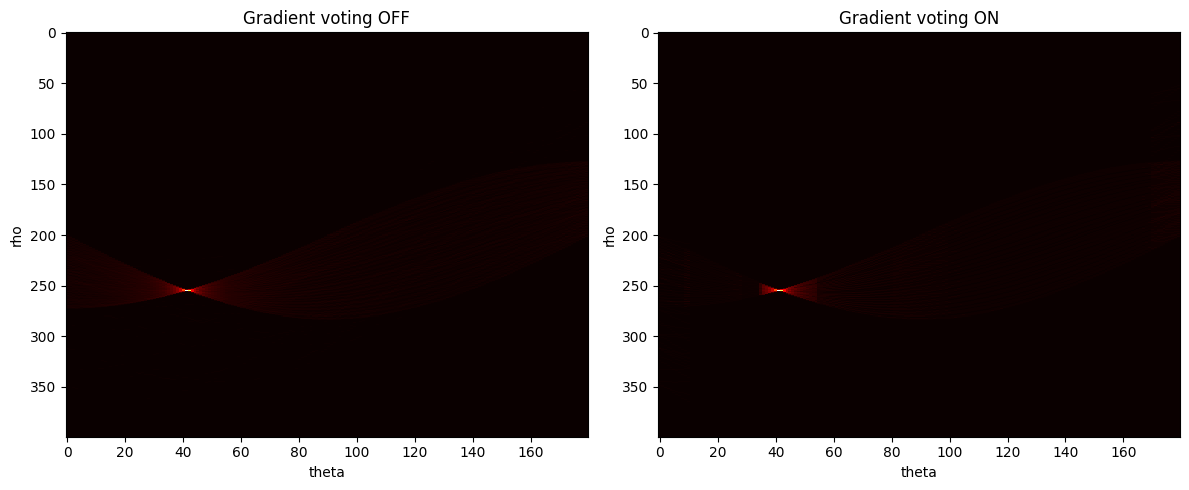

In [131]:
# TODO (b): bật/tắt bỏ phiếu theo hướng gradient

# Tính hướng gradient bằng hai nhân Sobel và convolve2d của nhóm.
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float64)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float64)
Gx = convolve2d(img_compare.astype(np.float64), sobel_x, mode="same")
Gy = convolve2d(img_compare.astype(np.float64), sobel_y, mode="same")
grad_dir = np.arctan2(Gy, Gx)

# Bản đồ biên của ảnh tổng hợp
edges = img_compare > 0

# Tham số dùng chung
n_theta = 180
n_rho = 400


# -------------------------
# 1. Gradient voting OFF
# -------------------------

A_off, theta_off, rho_off = hough_accumulate(
    edges,
    theta_range,
    rho_range,
    n_theta,
    n_rho,
    grad_dir=None
)



# -------------------------
# 2. Gradient voting ON
# -------------------------

A_on, theta_on, rho_on = hough_accumulate(
    edges,
    theta_range,
    rho_range,
    n_theta,
    n_rho,
    grad_dir=grad_dir,
    delta_deg=10
)



# -------------------------
# Hiển thị accumulator
# -------------------------

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)

plt.imshow(
    A_off,
    cmap="hot",
    aspect="auto"
)

plt.title(
    "Gradient voting OFF"
)

plt.xlabel("theta")

plt.ylabel("rho")



plt.subplot(1,2,2)

plt.imshow(
    A_on,
    cmap="hot",
    aspect="auto"
)

plt.title(
    "Gradient voting ON"
)

plt.xlabel("theta")

plt.ylabel("rho")


plt.tight_layout()

plt.show()

**Nhận xét (b):**

- Bảng được tính lại trực tiếp mỗi lần chạy notebook; không ghi cứng số thời gian từ một lần chạy cũ vì thời gian phụ thuộc máy và trạng thái hệ thống.
- Hough thô có accumulator nhỏ nên thường nhanh nhưng độ lượng tử hóa góc/rho lớn. Hough mịn giảm sai số lượng tử trên toàn miền, đổi lại phải tính nhiều ô hơn nên thường tốn thời gian nhất.
- Hough đa tỉ lệ chỉ tăng độ phân giải trong lân cận peak và, ở mỗi tầng, chỉ cho các điểm biên đã vote cho ô cha tham gia lại. Vì vậy nó hướng tới độ chính xác gần lưới mịn với ít phép tính hơn.
- `Peak/Background` của Hough đa tỉ lệ trong bảng được lấy từ accumulator cục bộ ở tầng tinh chỉnh cuối (`A_multi_final`), nên phản ánh peak đa tỉ lệ thay vì lặp lại chỉ số của accumulator thô. Do kích thước và tập voter của các accumulator khác nhau, chỉ số này cần được diễn giải cùng sai số góc và thời gian, không tách riêng.

### (c) Hai trường hợp bắt buộc có trong bộ ảnh

1. Một ảnh chứa **đường gần thẳng đứng** ($\theta_0$ quanh $0^\circ$ hoặc $179^\circ$).
2. Một ảnh chứa **đồng thời đoạn rất dài và đoạn rất ngắn**.

Cả hai đều là chỗ Hough một tỉ lệ hỏng. Chỉ rõ nó hỏng như thế nào.

### Có dùng AI hỗ trợ

**Công cụ:** ChatGPT (GPT-5.6 Sol)

**Mục đích:** Dựng kiểm thử Hough đa tỉ lệ với đường gần thẳng đứng ở 0.5° và 179.5°, cùng trường hợp có đồng thời đoạn rất dài và rất ngắn.

**Prompt đã dùng:**
> Hãy tạo các kiểm thử có ground truth 0.5°/179.5° để kiểm tra quấn vòng $\theta$ và đổi dấu $\rho$ trong Hough đa tỉ lệ; đồng thời tạo ảnh có một đoạn rất dài và một đoạn rất ngắn để chỉ ra giới hạn của Hough một tỉ lệ.

**Đã sửa lại những gì:**
- Tự chọn kích thước ảnh, độ dài đoạn, mức nhiễu và tham số các lưới Hough.
- Thay kiểm thử chỉ gọi `hough_accumulate` bằng kiểm thử gọi trực tiếp `hough_multiscale`.
- Tự đối chiếu sai số với ground truth và bổ sung nhận xét dựa trên kết quả chạy thực tế.

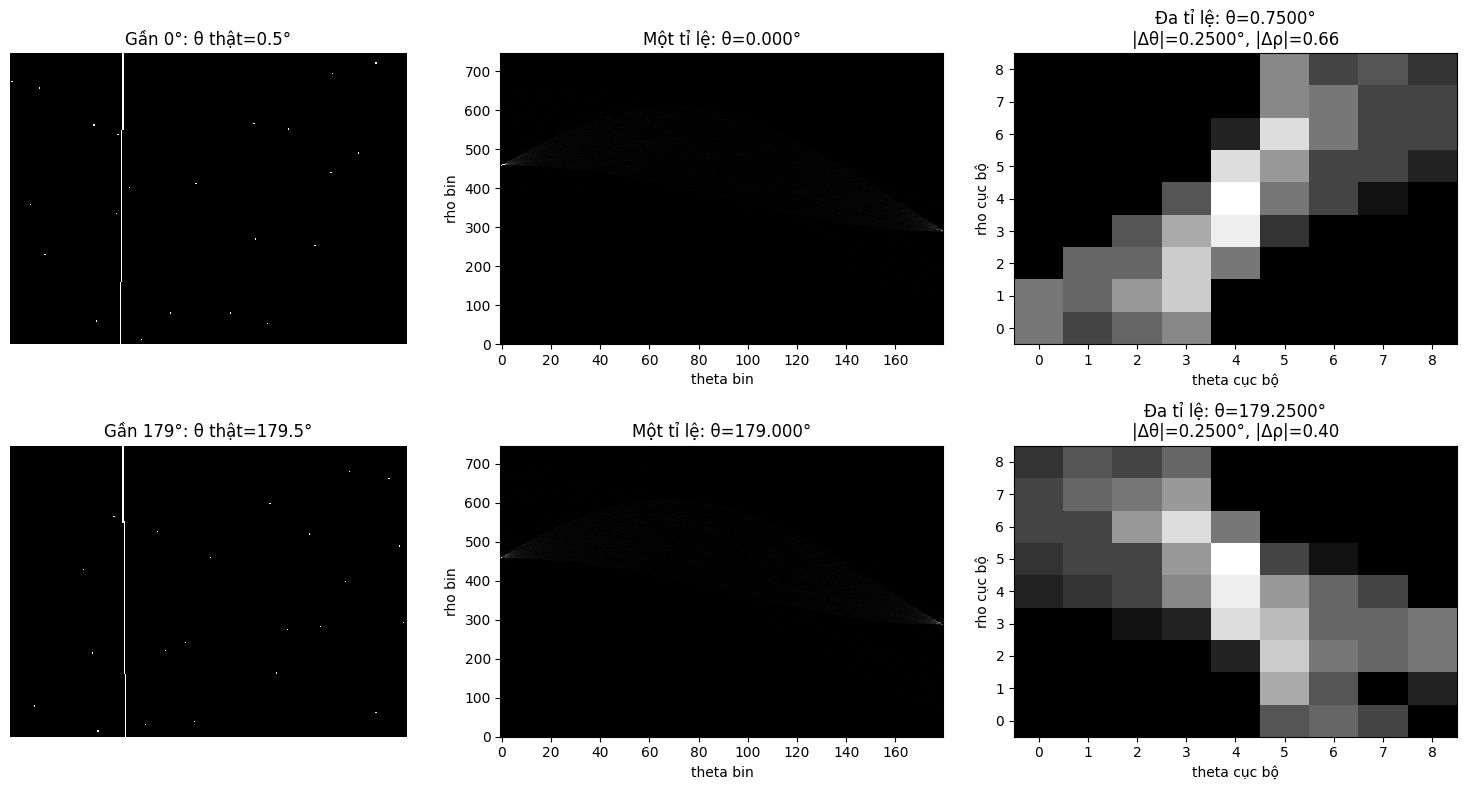

In [132]:
def aligned_hough_error(rho_hat, theta_hat, rho_true, theta_true):
    if not (np.isfinite(rho_hat) and np.isfinite(theta_hat)):
        return np.inf, np.inf
    turns = int(np.round((theta_hat - theta_true) / np.pi))
    theta_aligned = theta_hat - turns * np.pi
    rho_aligned = rho_hat * ((-1.0) ** turns)
    return abs(np.rad2deg(theta_aligned - theta_true)), abs(rho_aligned - rho_true)


vertical_cases = [
    {"name": "Gần 0°", "rho": 85.0, "theta_deg": 0.5},
    {"name": "Gần 179°", "rho": -85.0, "theta_deg": 179.5},
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, case in enumerate(vertical_cases):
    edges, _ = synthetic_lines(
        (220, 300),
        [{"rho": case["rho"], "theta_deg": case["theta_deg"]}],
        noise_frac=0.10,
        seed=20 + row
    )
    D = float(np.hypot(*edges.shape))
    A_single, theta_single, rho_single = hough_accumulate(
        edges > 0, (0.0, np.pi), (-D, D),
        n_theta=180, n_rho=2 * int(np.ceil(D)) + 1
    )
    single_index = np.unravel_index(np.argmax(A_single), A_single.shape)
    single_rho = float(rho_single[single_index[0]])
    single_theta = float(theta_single[single_index[1]])

    multi, multi_details = hough_multiscale(
        edges > 0, n_peaks=1, n_levels=3, refine_factor=4,
        n_theta0=180, n_rho0=2 * int(np.ceil(D)) + 1,
        return_details=True
    )
    rho_hat, theta_hat, _ = multi[0]
    error_theta, error_rho = aligned_hough_error(
        rho_hat, theta_hat, case["rho"], np.deg2rad(case["theta_deg"])
    )

    axes[row, 0].imshow(edges, cmap="gray")
    axes[row, 0].set_title(f'{case["name"]}: θ thật={case["theta_deg"]}°')
    axes[row, 0].axis("off")

    axes[row, 1].imshow(A_single, origin="lower", aspect="auto")
    axes[row, 1].set_title(f'Một tỉ lệ: θ={np.rad2deg(single_theta):.3f}°')
    axes[row, 1].set_xlabel("theta bin")
    axes[row, 1].set_ylabel("rho bin")

    axes[row, 2].imshow(multi_details[0]["accumulator"], origin="lower", aspect="auto")
    axes[row, 2].set_title(
        f'Đa tỉ lệ: θ={np.rad2deg(theta_hat):.4f}°\n'
        f'|Δθ|={error_theta:.4f}°, |Δρ|={error_rho:.2f}'
    )
    axes[row, 2].set_xlabel("theta cục bộ")
    axes[row, 2].set_ylabel("rho cục bộ")

plt.tight_layout()
plt.show()

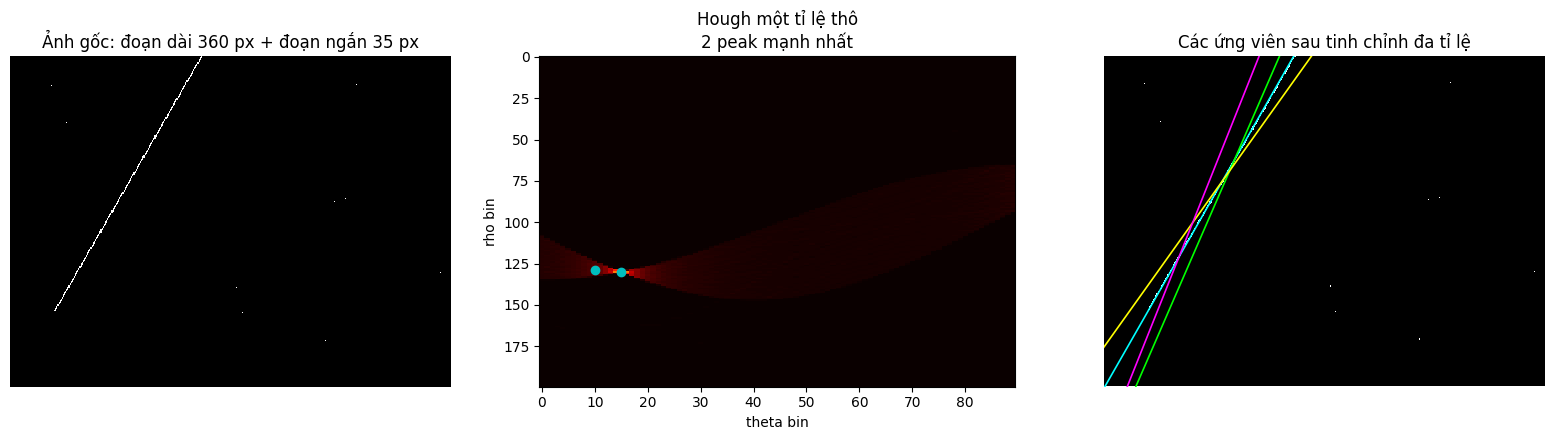

Ground truth:
rho=150.0, theta=30.0°, length=360 px
rho=80.0, theta=120.0°, length=35 px

Peak Hough thô:
rho=150.00, theta=30.00°, votes=306
rho=145.00, theta=20.00°, votes=33

Ứng viên Hough đa tỉ lệ:
rho=149.69, theta=29.75°, votes=84
rho=146.25, theta=23.50°, votes=5
rho=153.44, theta=35.50°, votes=5
rho=130.94, theta=21.75°, votes=4


In [133]:
# Trường hợp có đồng thời một đoạn rất dài và một đoạn rất ngắn.
H, W = 300, 400
mixed_spec = [
    {"rho": 150.0, "theta_deg": 30.0, "length": 360},
    {"rho": 80.0, "theta_deg": 120.0, "length": 35},
]
mixed_long_short, gt_mixed = synthetic_lines(
    (H, W), mixed_spec, noise_frac=0.03, seed=42
)
edges_mixed = mixed_long_short > 0
diag_mixed = np.hypot(H, W)

A_coarse_m, theta_c_m, rho_c_m = hough_accumulate(
    edges_mixed, (0.0, np.pi), (-diag_mixed, diag_mixed),
    n_theta=90, n_rho=200
)
coarse_peaks_m = find_peaks(A_coarse_m, n_peaks=2, nms_radius=4)
multi_m, details_m = hough_multiscale(
    edges_mixed, n_peaks=8, n_levels=3, refine_factor=4,
    n_theta0=90, n_rho0=200, return_details=True
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].imshow(mixed_long_short, cmap="gray")
axes[0].set_title("Ảnh gốc: đoạn dài 360 px + đoạn ngắn 35 px")
axes[0].axis("off")

axes[1].imshow(A_coarse_m, cmap="hot", aspect="auto")
for ir, it, _ in coarse_peaks_m:
    axes[1].plot(it, ir, "co")
axes[1].set_title("Hough một tỉ lệ thô\n2 peak mạnh nhất")
axes[1].set_xlabel("theta bin")
axes[1].set_ylabel("rho bin")

axes[2].imshow(mixed_long_short, cmap="gray")
colors = ["cyan", "lime", "yellow", "magenta"]
for color, (rho, theta, votes) in zip(colors, multi_m[:4]):
    _ve_duong(axes[2], rho, theta, H, W, color=color)
axes[2].set_xlim(0, W)
axes[2].set_ylim(H, 0)
axes[2].set_title("Các ứng viên sau tinh chỉnh đa tỉ lệ")
axes[2].axis("off")
plt.tight_layout()
plt.show()

print("Ground truth:")
for item in gt_mixed:
    print(
        f"rho={item['rho']:.1f}, theta={item['theta_deg']:.1f}°, "
        f"length={item['length']} px"
    )
print("\nPeak Hough thô:")
for ir, it, votes in coarse_peaks_m:
    print(f"rho={rho_c_m[ir]:.2f}, theta={np.rad2deg(theta_c_m[it]):.2f}°, votes={votes}")
print("\nỨng viên Hough đa tỉ lệ:")
for rho, theta, votes in multi_m[:4]:
    print(f"rho={rho:.2f}, theta={np.rad2deg(theta):.2f}°, votes={votes}")

**Nhận xét (c):**

- Với các đường 0.5° và 179.5°, kiểm thử gọi trực tiếp `hough_multiscale()`. Hai góc nằm sát hai đầu miền $[0,\pi)$ nên cửa sổ tinh chỉnh có thể vượt biên. Khi quấn $\theta$ thêm/bớt $\pi$, thuật toán phải đồng thời đổi dấu $\rho$ vì $(\rho,\theta)$ và $(-\rho,\theta+\pi)$ biểu diễn cùng một đường. Accumulator tầng cuối và sai số in trên hình cho phép phát hiện lỗi quấn vòng trong chính quá trình coarse-to-fine.

- Ảnh dài–ngắn thật sự chứa đoạn dài 360 px và đoạn ngắn 35 px. Trong kết quả đang in, peak mạnh nhất của Hough thô khớp đoạn dài ở 30°, còn peak thứ hai không khớp đoạn ngắn 120°; đoạn ngắn đã chìm dưới các peak do nhiễu. Đây là chỗ Hough một tỉ lệ hỏng: một ngưỡng phiếu đủ cao để tránh nhiễu có thể đồng thời loại đoạn ngắn.

- Hough đa tỉ lệ không tự loại bỏ hoàn toàn thiên lệch theo độ dài, nhưng có thể giữ nhiều ứng viên thô rồi tinh chỉnh từng vùng bằng chính tập voter của ô cha. Danh sách ứng viên và hình chồng đường giúp kiểm tra đoạn ngắn có được giữ lại hay không; nếu không, cần tăng số ứng viên ban đầu hoặc dùng tiêu chuẩn chuẩn hóa theo độ dài, thay vì khẳng định trước rằng đoạn ngắn đã được phát hiện.

---
---
## Trước khi nộp

- [ ] Ba mục **Cài đặt** không còn `raise NotImplementedError`, và không có ô nào trong đó gọi
      `cv2` / `scipy` / `skimage`.
- [ ] Mỗi ô mã ở phần thí nghiệm có dùng AI đều có ô khai báo prompt ngay phía trên.
- [ ] Notebook chạy được từ đầu đến cuối (`Kernel → Restart & Run All`) không lỗi.
- [ ] Ảnh dùng trong bài đã được nộp kèm, hoặc mã sinh ảnh nằm ngay trong notebook.
- [ ] Đã điền tên nhóm và danh sách thành viên ở đầu notebook.